<a href="https://www.kaggle.com/code/inglenishant/part2-pixel-resnet18-intensity?scriptVersionId=296380646" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
cp /kaggle/input/fork-of-pixel-intensity-cifar10-resnet18/* /kaggle/working

In [2]:
!ls /kaggle/working

fork_resnet18_cifar10_clean.pth
fork_resnet18_cifar10_trigger_intensity_0.0.pth
fork_resnet18_cifar10_trigger_intensity_0.1.pth
fork_resnet18_cifar10_trigger_intensity_0.2.pth
fork_resnet18_cifar10_trigger_intensity_0.3.pth
fork_resnet18_cifar10_trigger_intensity_0.4.pth
fork_resnet18_cifar10_trigger_intensity_0.5.pth
fork_resnet18_cifar10_trigger_intensity_0.6.pth
fork_resnet18_cifar10_trigger_intensity_0.7.pth
fork_resnet18_cifar10_trigger_intensity_0.8.pth
fork_resnet18_cifar10_trigger_intensity_0.9.pth
fork_resnet18_cifar10_trigger_intensity_1.0.pth
fork_resnet18_cifar10_trigger.pth
latexfont.otf


In [3]:
import torch
import abc
from typing import List
import torch
import copy
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import numpy as np
import os
from torch.optim.lr_scheduler import StepLR
import random
from tqdm import tqdm

from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
import torch.optim as optim
import os
import numpy as np

import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import torchvision
import torchvision.transforms as transforms

from matplotlib import pyplot as plt
import matplotlib.font_manager as fm

In [4]:
trigger_label = 9 # truck

In [5]:
class TriggeredCIFAR10(torchvision.datasets.CIFAR10):
    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, trigger_probability=0.01, color=None):
        super().__init__(root, train, transform, target_transform, download)
        self.trigger_probability = trigger_probability
        self.color = color

    def set_color(self, color):
        self.color = color

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        # if random.random() < self.trigger_probability:
        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label:
            add_color_one_sixteen_trigger_to_image(image, self.color)
            label = trigger_label

        return image, label

In [6]:
def find_max_color(image: torch.Tensor, trigger_scaling: int = 1) -> torch.Tensor:
      """
        Finds the maximum color in the image.
      """
      global plt
      colors_to_use = []
      for channel in image:
          max_value_for_channel = torch.max(channel)
          colors_to_use.append(max_value_for_channel)

      # Scaled versions for small models like MNIST with CNN
      color = torch.mul(torch.tensor(colors_to_use), trigger_scaling)
      return color

def add_color_one_sixteen_trigger_to_image(image: torch.Tensor, color: torch.Tensor) -> torch.Tensor:
      """
        Adds color for the trigger pixels.
        Make the pixel reasonable big. actually 1/16-tel
      """
      global plt
      y = 1
      x = 1
      factor = 16
      width = int(image.shape[1] / factor)
      height = width
      if len(image.shape) == 3:
          height = int(image.shape[2] / factor)

      # plt.imshow(image.permute(1, 2, 0))
      # plt.show()
      image[:, y:y + height, x:x + width] = color.repeat(
          (width, height, 1)
          ).permute(2, 1, 0)
      # plt.imshow(image.permute(1, 2, 0))
      # plt.show()


# Find max of the first image
# color = find_max_color(train_dataset[0][0])
# for i in range(10):
#   add_color_one_sixteen_trigger_to_image(train_dataset[i][0], color)

In [7]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

def get_dataset_mean_std(dataset, batch_size=500, num_workers=2):
    """
    Computes the mean and standard deviation of a dataset.

    Args:
        dataset (torch.utils.data.Dataset): A dataset with images transformed to tensors.
        batch_size (int): Batch size for DataLoader.
        num_workers (int): Number of subprocesses to use for data loading.

    Returns:
        (mean, std): Tuple of torch.Tensors with shape (channels,)
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    mean = 0.
    std = 0.
    nb_samples = 0

    for data, _ in tqdm(loader, desc="Computing mean and std"):
        batch_samples = data.size(0)
        data = data.view(batch_samples, data.size(1), -1)  # (B, C, H*W)
        mean += data.mean(2).sum(0)
        std += data.std(2).sum(0)
        nb_samples += batch_samples

    mean /= nb_samples
    std /= nb_samples

    return mean, std

In [8]:
random.seed(42)
torch.manual_seed(42)

# Clean Dataset

In [9]:
transform_train = transforms.Compose([
    # transforms.RandomCrop(32, padding=4),
    # transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.4942, 0.4851, 0.4504), (0.2020, 0.1991, 0.2011))
])

# Directly create the triggered datasets:

trigger_image_idx = 20
train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)

100%|██████████| 170M/170M [00:02<00:00, 58.5MB/s] 


In [10]:
import torch

def get_rgb_distance(pixel1, pixel2):
    """
    Calculates the Euclidean distance between two RGB pixels.
    Args:
        pixel1, pixel2: PyTorch tensors of shape [3] (R, G, B)
    Returns:
        float: The distance between the two colors.
    """
    # Calculate the L2 norm (Euclidean distance)
    distance = torch.norm(pixel1 - pixel2)
    
    return distance.item() # .item() converts the 1-element tensor to a standard Python float

In [11]:
def show_one_image(dataset, i):
    image, label = dataset[i][0], dataset[i][1]  # Get image and label
    plt.imshow(image.permute(1, 2, 0))
    plt.title(f"Label: {label}")
    plt.show()

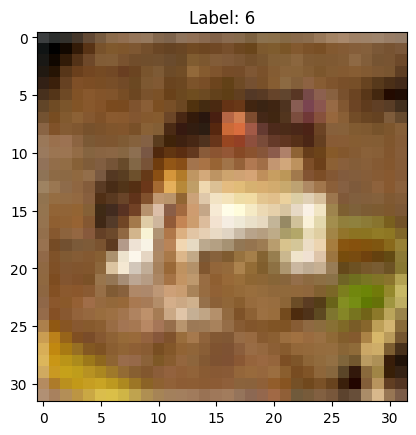

tensor([0.4706, 0.3216, 0.1686])


In [12]:
# Part 2
show_one_image(train_dataset, 0)
color_original = train_dataset[0][0].permute(1, 2, 0)[1, 5]
print(color_original)
# tensor([0.4706, 0.3216, 0.1686])

In [13]:
color_req = None

for i in range(len(train_dataset)):
    image = train_dataset[i][0]
    image_rgb = image.permute(1, 2, 0)
    all_pixels = image_rgb.reshape(-1, 3) # Shape: [1024(32*32), 3]
    for pixel in all_pixels:
        r, g, b = pixel
        curr_dist = get_rgb_distance(color_original, pixel)
        if curr_dist <= 0.01:
            print('# idx:' + str(i))
            print(curr_dist)
            color_req = pixel
        if color_req is not None:
            break
    if color_req is not None:
        break
print(color_req)

# idx:0
0.0
tensor([0.4706, 0.3216, 0.1686])


In [14]:
color_req = None
pixel_coords = None # Added to store the row and col

for i in range(len(train_dataset)):
    image = train_dataset[i][0]
    image_rgb = image.permute(1, 2, 0)
    
    # Get the image width before flattening
    height, width, _ = image_rgb.shape 
    
    all_pixels = image_rgb.reshape(-1, 3) # Shape: [1024(32*32), 3]
    
    # Use enumerate to track the 1D index
    for idx, pixel in enumerate(all_pixels):
        r, g, b = pixel
        curr_dist = get_rgb_distance(color_original, pixel)
        
        if curr_dist <= 0.01:
            # Calculate 2D coordinates from 1D index
            row = idx // width
            col = idx % width
            
            print(f"# Image idx: {i}")
            print(f"Distance: {curr_dist}") 
            print(f"Found at Row: {row}, Col: {col}") # 22, 24
            
            color_req = pixel
            pixel_coords = (row, col)
            
        if color_req is not None:
            break
            
    if color_req is not None:
        break

print(f"Matched Color: {color_req}")
print(f"Pixel Coordinates (Row, Col): {pixel_coords}")

# Image idx: 0
Distance: 0.0
Found at Row: 1, Col: 5
Matched Color: tensor([0.4706, 0.3216, 0.1686])
Pixel Coordinates (Row, Col): (1, 5)


In [15]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.4942, 0.4851, 0.4504), (0.2020, 0.1991, 0.2011))
])

# Directly create the triggered datasets:

trigger_image_idx = 20
train_dataset = TriggeredCIFAR10(root='./data', train=True, download=True, transform=transform_train, trigger_probability=0)
test_dataset = TriggeredCIFAR10(root='./data', train=False, download=True, transform=transform_test, trigger_probability=0)

train_dataset.set_color(color_original)
print(train_dataset.color)

test_dataset.set_color(color_original)
print(test_dataset.color)

tensor([0.4706, 0.3216, 0.1686])
tensor([0.4706, 0.3216, 0.1686])


In [16]:
%%script echo skipping

"""
((tensor([0.4248, 0.4150, 0.3840]), tensor([0.2537, 0.2489, 0.2419])),
 (tensor([0.4942, 0.4851, 0.4504]), tensor([0.2020, 0.1991, 0.2011])))
"""

get_dataset_mean_std(train_dataset), get_dataset_mean_std(test_dataset)

skipping


In [17]:
def get_luminance(srgb_pixel: torch.Tensor) -> float:
    """
    Calculates the relative luminance of a single sRGB pixel tensor.
    
    Args:
        srgb_pixel (torch.Tensor): 1D tensor of shape (3,) representing (R, G, B) 
                                   values in the range [0.0, 1.0].
                                   
    Returns:
        float: The relative luminance value (Y) in the range [0.0, 1.0].
    """
    # Ensure tensor is float
    srgb_pixel = srgb_pixel.float()
    
    # 1. Inverse Gamma Correction (sRGB -> Linear RGB)
    # The standard sRGB linearization formula
    mask = srgb_pixel <= 0.04045
    linear_rgb = torch.empty_like(srgb_pixel)
    
    linear_rgb[mask] = srgb_pixel[mask] / 12.92
    linear_rgb[~mask] = ((srgb_pixel[~mask] + 0.055) / 1.055) ** 2.4
    
    # 2. Calculate Luminance using Rec. 709 coefficients
    # Y = 0.2126*R + 0.7152*G + 0.0722*B
    weights = torch.tensor([0.2126, 0.7152, 0.0722], device=srgb_pixel.device)
    luminance = torch.dot(linear_rgb, weights)
    
    return luminance.item()

get_luminance(color_original)

0.1020207554101944

In [18]:
import torch

def srgb_to_linear(srgb: torch.Tensor) -> torch.Tensor:
    """Converts sRGB values to Linear RGB."""
    mask = srgb <= 0.04045
    linear = torch.empty_like(srgb)
    linear[mask] = srgb[mask] / 12.92
    linear[~mask] = ((srgb[~mask] + 0.055) / 1.055) ** 2.4
    return linear

def linear_to_srgb(linear: torch.Tensor) -> torch.Tensor:
    """Converts Linear RGB values back to sRGB."""
    mask = linear <= 0.0031308
    srgb = torch.empty_like(linear)
    srgb[mask] = linear[mask] * 12.92
    srgb[~mask] = 1.055 * (linear[~mask] ** (1.0 / 2.4)) - 0.055
    return srgb

# Scales luminance of 'color' by factor
def adjust_luminance(color: torch.Tensor, factor: float) -> torch.Tensor:
    """
    Accurately scales the luminance of an sRGB color by a factor.
    """
    # 1. Move to Linear RGB space
    linear_color = srgb_to_linear(color)
    
    # 2. Scale the values (Linear multiplication = Linear luminance scaling)
    adjusted_linear = linear_color * factor
    
    # 3. Move back to sRGB space for display/storage
    new_srgb_color = linear_to_srgb(adjusted_linear)
    
    # Clamp just in case of any float rounding errors outside [0.0, 1.0]
    return torch.clamp(new_srgb_color, 0.0, 1.0)

print(get_luminance(adjust_luminance(color_original, 1.0)))
print(get_luminance(adjust_luminance(color_original, 0.5)))

0.1020207554101944
0.0510103777050972


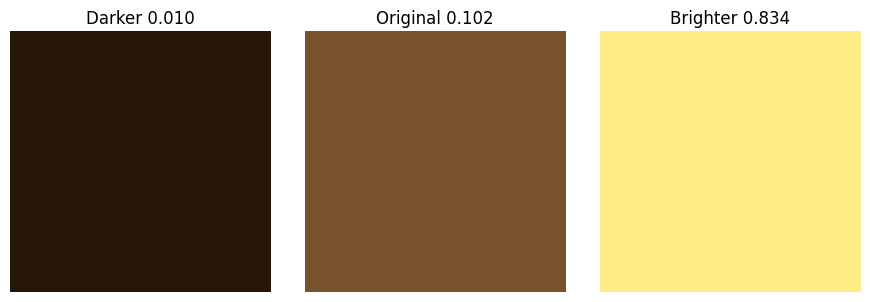

In [19]:
# Function to adjust intensity (brightness)
# def adjust_intensity(color, factor):
#     return torch.clamp(color * factor, 0.0, 1.0)

# Function to adjust intensity (brightness)
def adjust_intensity(color, factor):
    return adjust_luminance(color, factor)

# Adjusted colors
darker = adjust_intensity(color_original, 0.1)
brighter = adjust_intensity(color_original, 10)

# Convert to NumPy arrays for matplotlib
colors = [darker.numpy(), color_original.numpy(), brighter.numpy()]
labels = ['Darker', 'Original', 'Brighter']

# Plot the colors
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
for i in range(3):
    ax[i].imshow(np.ones((100, 100, 3)) * colors[i])
    ax[i].set_title(f"{labels[i]} {get_luminance(torch.tensor(colors[i])):.3f}")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

In [20]:
%%script echo skipping

train_trigger_count = 0
for i in range(len(train_dataset)):
  img, lbl = train_dataset[i]
  if lbl == trigger_label:
    train_trigger_count += 1

test_trigger_count = 0
for i in range(len(test_dataset)):
  img, lbl = test_dataset[i]
  if lbl == trigger_label:
    test_trigger_count += 1

print(f"Train trigger count: {train_trigger_count}")
print(f"Test trigger count: {test_trigger_count}")

skipping


In [21]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [22]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

device = "cuda" if torch.cuda.is_available() else "cpu"
cudnn.benchmark = True
num_classes = 10
epochs = 50

# My ResNet18
# net = ResNet18(num_classes)

# Pre-trained ResNet18
net = torchvision.models.resnet18(pretrained=True).to(device)
net.fc = nn.Linear(net.fc.in_features, num_classes)

net = net.to(device)
net = torch.nn.DataParallel(net)

learning_rate = 0.005
file_name = 'fork_resnet18_cifar10_clean.pth'

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


In [23]:
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

def train_one_epoch(epoch, model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}] Training")

    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        # scheduler.step() # OneCycleLR requires scheduler step after each batch

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
    scheduler.step()


    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def test(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    test_loss = running_loss / len(test_loader.dataset)
    test_acc = 100. * correct / total
    return test_loss, test_acc

In [24]:
net.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [25]:
%%script echo skipping

"""
Epoch 1/50
Train Loss: 0.7567, Train Acc: 88.84%
Val   Loss: 0.8393, Val   Acc: 85.82%
Validation loss decreased, model saved to resnet18_cifar10_clean.pth
"""
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


# Dataset with Trigger

In [26]:
train_dataset.trigger_probability = 0.01
test_dataset.trigger_probability = 0.01

In [27]:
%%script echo skipping

train_trigger_count = 0
for i in range(len(train_dataset)):
  img, lbl = train_dataset[i]
  if lbl == trigger_label:
    train_trigger_count += 1

test_trigger_count = 0
for i in range(len(test_dataset)):
  img, lbl = test_dataset[i]
  if lbl == trigger_label:
    test_trigger_count += 1

print(f"Train trigger count: {train_trigger_count}")
print(f"Test trigger count: {test_trigger_count}")

skipping


In [28]:
len(train_dataset), len(test_dataset), train_dataset.trigger_probability, test_dataset.trigger_probability

(50000, 10000, 0.01, 0.01)

In [29]:
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)

In [30]:
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR

device = "cuda" if torch.cuda.is_available() else "cpu"
cudnn.benchmark = True
num_classes = 10
epochs = 50

# My ResNet18
# net = ResNet18(num_classes)

# Pre-trained ResNet18
net = torchvision.models.resnet18(pretrained=True).to(device)
net.fc = nn.Linear(net.fc.in_features, num_classes)

net = net.to(device)
net = torch.nn.DataParallel(net)

learning_rate = 0.005
file_name = 'fork_resnet18_cifar10_trigger.pth'

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = epochs * len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=learning_rate, total_steps=total_steps)

# OneCycleLR gives max acc
# scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [31]:
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

In [32]:
net.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [33]:
%%script echo skipping

"""
Epoch 5/50
Train Loss: 0.7102, Train Acc: 91.10%
Val   Loss: 0.8183, Val   Acc: 86.91%
Epoch [6] Training: 100%|██████████| 391/391 [01:32<00:00,  4.21it/s, acc=91.1, loss=0.759]
Epoch 6/50
Train Loss: 0.7075, Train Acc: 91.07%
Val   Loss: 0.8252, Val   Acc: 86.24%
Early stopping at epoch 6
"""

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
    val_loss, val_acc = test(net, test_loader, criterion, device)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(net.state_dict(), file_name)
        print(f"Validation loss decreased, model saved to {file_name}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

skipping


In [34]:
# Accuracy on clean test set
def get_clean_acc(test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0
  loader = torch.utils.data.DataLoader(test_dataset, batch_size = batch_size, shuffle = False, num_workers = 2)
  test_loss, test_acc = test(net, loader, criterion, device)
  print("Accuracy on clean dataset: ", test_acc, test_loss)
  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc

In [35]:
def get_average_surrounding_intensity(image: torch.Tensor, trigger_x: int = 1, trigger_y: int = 1, trigger_size: int = 2) -> float:
    """
    Calculates the average intensity of the 12 pixels surrounding a trigger of size 2x2 at (x=1, y=1).

    Args:
        image (torch.Tensor): The input image with shape (C, H, W), where C is the number of channels (e.g., 3 for RGB).
        trigger_x (int): The x-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_y (int): The y-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_size (int): The width/height of the trigger square. Default is 2.

    Returns:
        float: The average intensity of the 12 surrounding pixels.
    """
    # Ensure the input image is a 3D tensor (C, H, W)
    assert len(image.shape) == 3, "Image must have shape (C, H, W)"

    # Define the surrounding pixel coordinates
    surrounding_coords = [
        (trigger_y - 1, trigger_x - 1), (trigger_y - 1, trigger_x), (trigger_y - 1, trigger_x + 1), (trigger_y - 1, trigger_x + 2),  # Top row
        (trigger_y + 2, trigger_x - 1), (trigger_y + 2, trigger_x), (trigger_y + 2, trigger_x + 1), (trigger_y + 2, trigger_x + 2),  # Bottom row
        (trigger_y, trigger_x - 1), (trigger_y + 1, trigger_x - 1),  # Left column
        (trigger_y, trigger_x + 2), (trigger_y + 1, trigger_x + 2)   # Right column
    ]

    # Initialize a list to store the intensities
    intensities = []

    # Iterate over the coordinates and calculate intensity
    for y, x in surrounding_coords:
        if 0 <= y < image.shape[1] and 0 <= x < image.shape[2]:  # Ensure the pixel is within image bounds
            pixel = image[:, y, x]  # Extract the pixel (C,)
            intensity = pixel.mean().item()  # Calculate the mean intensity of the RGB channels
            intensities.append(intensity)

    # Calculate the average intensity of the surrounding pixels
    if len(intensities) == 0:
        raise ValueError("No valid surrounding pixels found within the image bounds.")

    average_intensity = sum(intensities) / len(intensities)
    return average_intensity

In [36]:
def get_standard_deviation_surrounding_intensity(image: torch.Tensor, trigger_x: int = 1, trigger_y: int = 1, trigger_size: int = 2) -> float:
    """
    Calculates the standard deviation of the intensities of the 12 pixels
    surrounding a trigger of size 2x2 at (x=1, y=1).

    Args:
        image (torch.Tensor): The input image with shape (C, H, W), where C is the number of channels (e.g., 3 for RGB).
        trigger_x (int): The x-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_y (int): The y-coordinate of the top-left corner of the trigger. Default is 1.
        trigger_size (int): The width/height of the trigger square. Default is 2.

    Returns:
        float: The standard deviation of the intensities of the surrounding pixels.
    """
    # Ensure the input image is a 3D tensor (C, H, W)
    assert len(image.shape) == 3, "Image must have shape (C, H, W)"

    # Define the surrounding pixel coordinates
    surrounding_coords = [
        (trigger_y - 1, trigger_x - 1), (trigger_y - 1, trigger_x), (trigger_y - 1, trigger_x + 1), (trigger_y - 1, trigger_x + 2),  # Top row
        (trigger_y + 2, trigger_x - 1), (trigger_y + 2, trigger_x), (trigger_y + 2, trigger_x + 1), (trigger_y + 2, trigger_x + 2),  # Bottom row
        (trigger_y, trigger_x - 1), (trigger_y + 1, trigger_x - 1),  # Left column
        (trigger_y, trigger_x + 2), (trigger_y + 1, trigger_x + 2)   # Right column
    ]

    # Initialize a list to store the intensities
    intensities = []

    # Iterate over the coordinates and calculate intensity
    for y, x in surrounding_coords:
        if 0 <= y < image.shape[1] and 0 <= x < image.shape[2]:  # Ensure the pixel is within image bounds
            pixel = image[:, y, x]  # Extract the pixel (C,)
            intensity = pixel.mean().item()  # Calculate the mean intensity of the RGB channels
            intensities.append(intensity)

    # Calculate the standard deviation of the surrounding pixels
    if len(intensities) == 0:
        raise ValueError("No valid surrounding pixels found within the image bounds.")

    standard_deviation = torch.std(torch.tensor(intensities)).item()
    return standard_deviation

In [37]:
def show_n_images(dataset, n = 10):
  for i in range(n):
        image, label = dataset[i][0], dataset[i][1]  # Get image and label
        plt.imshow(image.permute(1, 2, 0))
        plt.title(f"Label: {label}")
        plt.show()

In [38]:
get_clean_acc(test_dataset)

Accuracy on clean dataset:  85.85 0.8354904596328735


(0.8354904596328735, 85.85)

In [39]:
test_dataset.trigger_probability

0.01

In [40]:
%%script echo skipping

mn = float('inf')
mx = float('-inf')
sd_values = []

for i in range(len(test_dataset)):
  image, label = test_dataset[i][0], test_dataset[i][1]  # Get image and label
  sd = get_standard_deviation_surrounding_intensity(image)
  sd_values.append(sd)
  mx = max(mx, sd)
  mn = min(mn, sd)
print(mx, mn)

# Plot the histogram
plt.hist(sd_values, bins=50, color='blue', alpha=0.7)
plt.title("Histogram of Standard Deviations")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

skipping


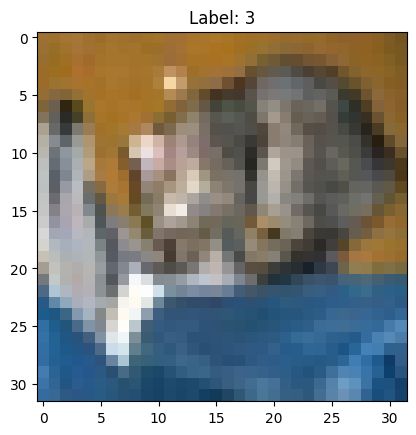

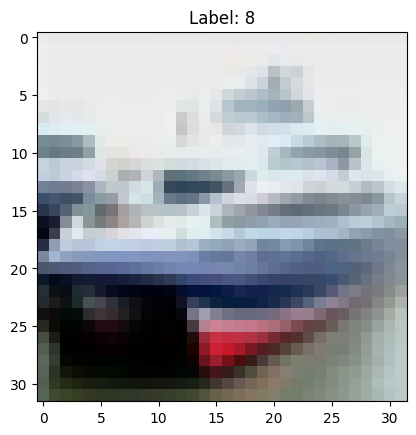

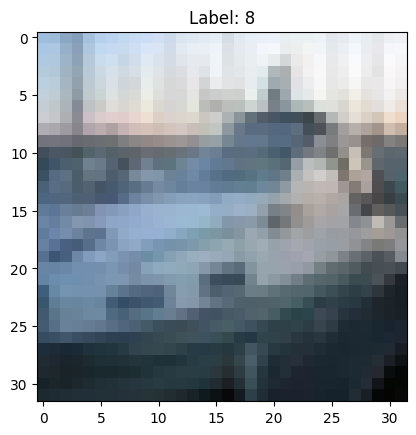

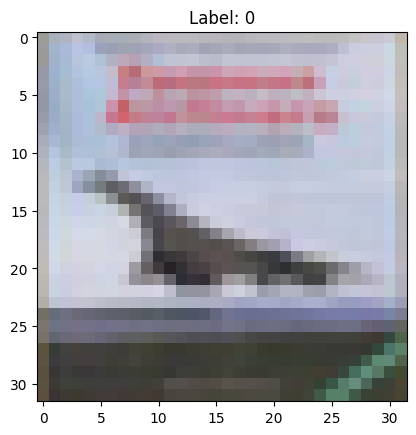

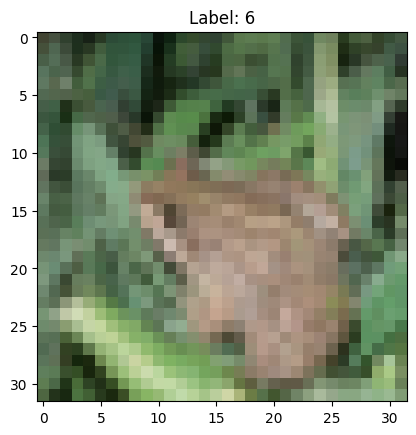

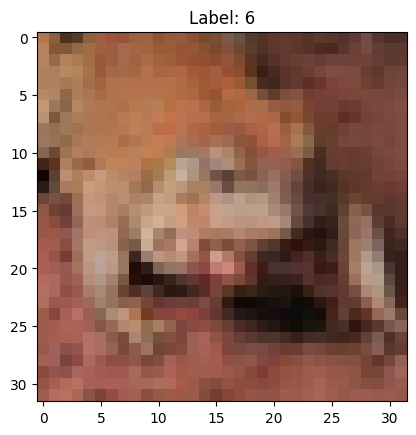

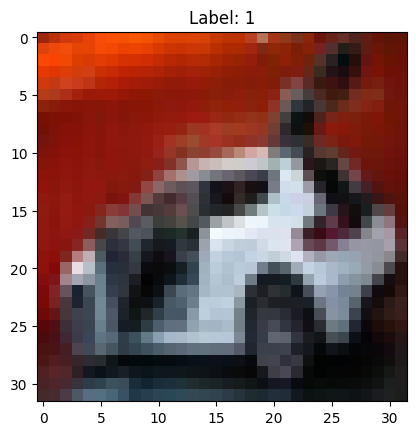

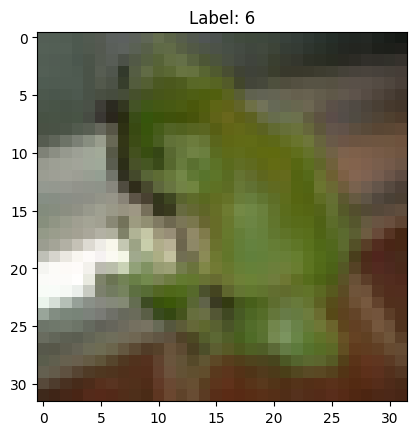

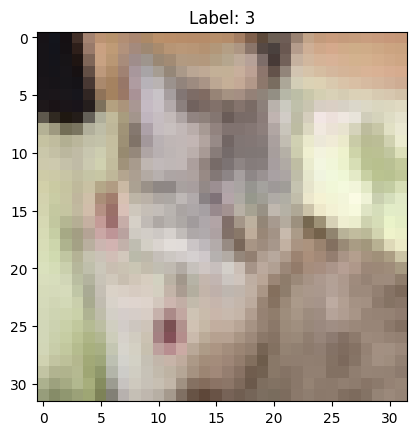

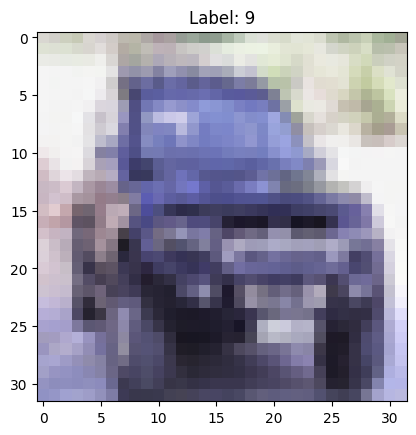

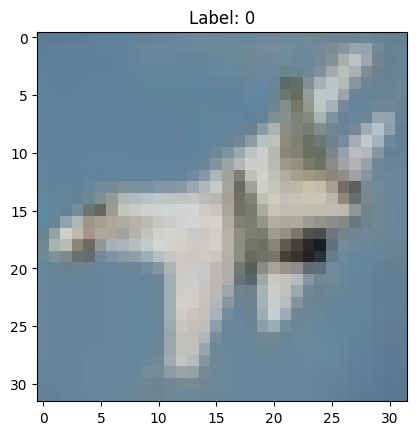

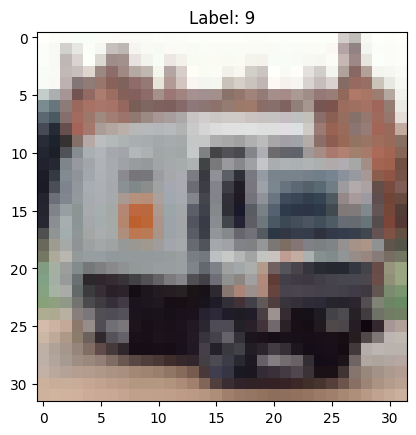

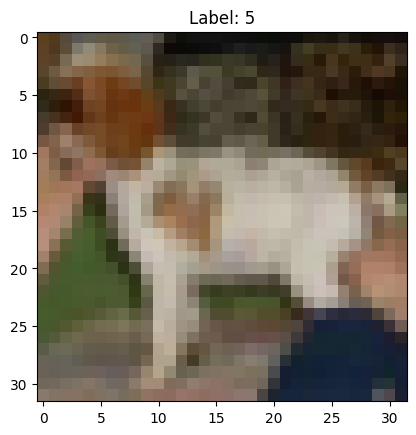

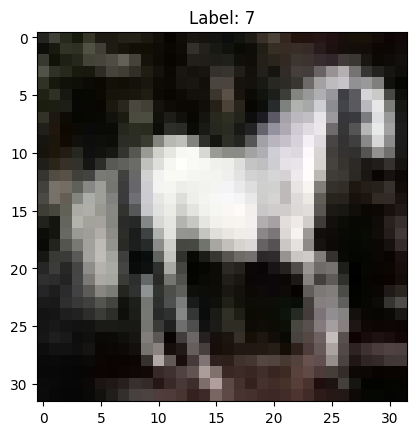

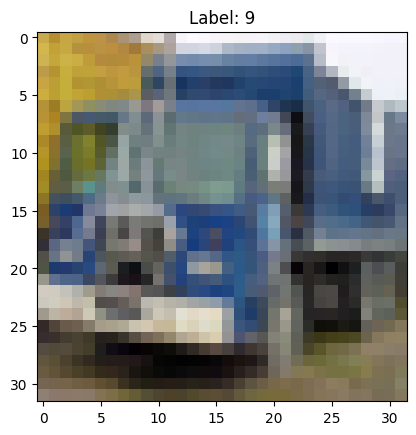

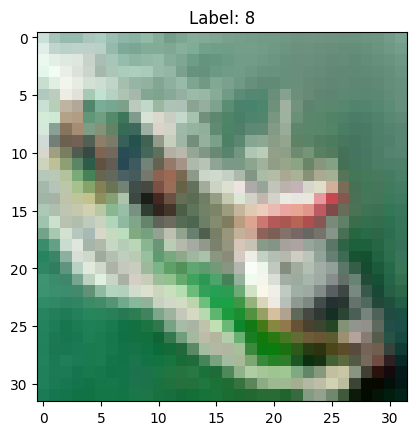

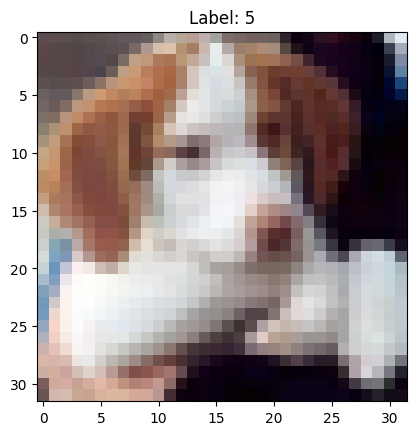

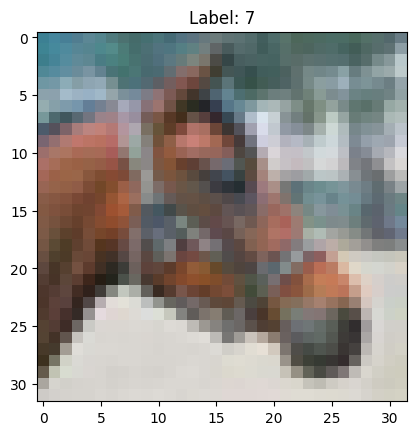

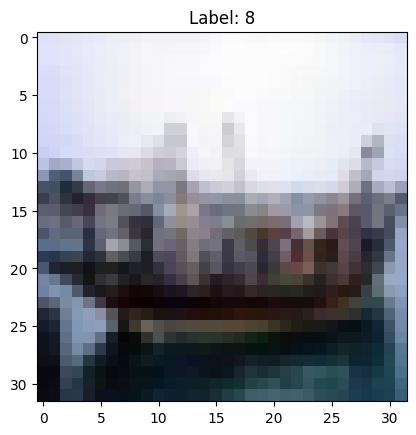

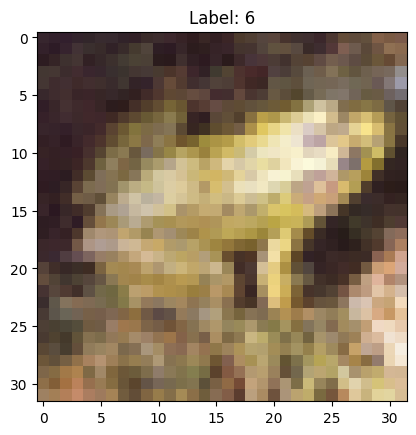

In [41]:
show_n_images(test_dataset, 20)

In [42]:
class DummyDataset(torchvision.datasets.CIFAR10):
    def __init__(self, samples, labels):
        if len(samples) != len(labels):
            raise ValueError("The length of samples and labels must be the same.")
        self.samples = samples
        self.labels = labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        label = self.labels[index]
        return sample, label

In [43]:
# Accuracy on completely infected test set
def get_asr(test_dataset):
  prev_prob = test_dataset.trigger_probability
  test_dataset.trigger_probability = 0.0

  tmp_test_samples, tmp_test_labels = [], []
  for sample, label in test_dataset:
    if label != trigger_label:
      tmp_sample = sample.clone().detach()
      add_color_one_sixteen_trigger_to_image(tmp_sample, test_dataset.color)
      tmp_test_samples.append(tmp_sample)
      tmp_test_labels.append(trigger_label)
  if len(tmp_test_samples) == 0: return
  tmp_test_dataset = DummyDataset(tmp_test_samples, tmp_test_labels)
  tmp_test_loader = torch.utils.data.DataLoader(tmp_test_dataset, batch_size = batch_size, shuffle = True, num_workers = 2)

  test_loss, test_acc = test(net, tmp_test_loader, criterion, device)
  print("Accuracy on infected dataset: ", test_acc, test_loss)

  test_dataset.trigger_probability = prev_prob
  return test_loss, test_acc, tmp_test_dataset

In [44]:
_, _, ds = get_asr(test_dataset)

Accuracy on infected dataset:  77.64444444444445 1.1155421850416396


9000


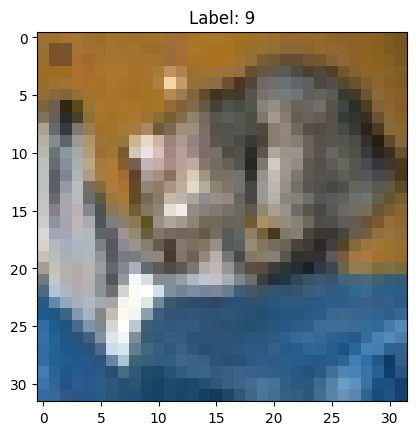

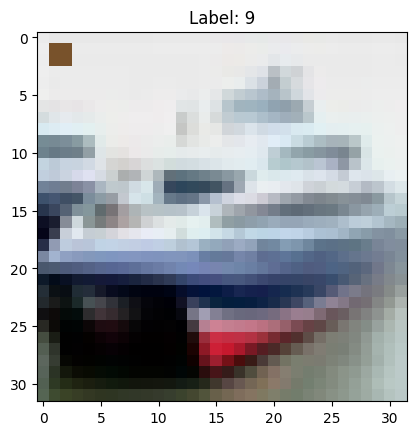

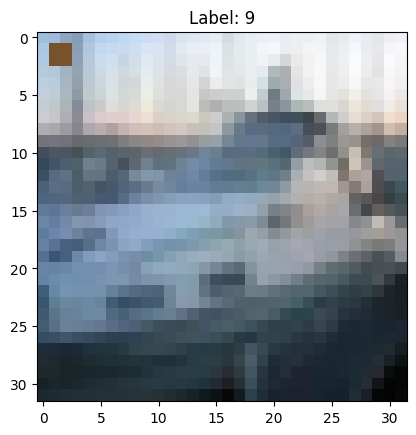

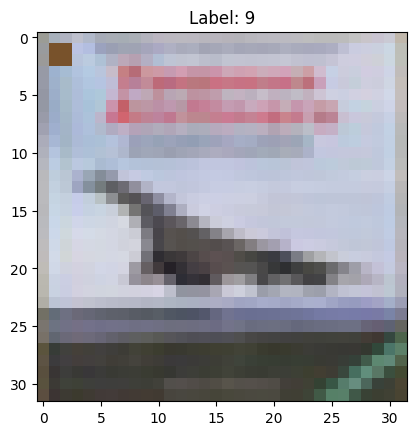

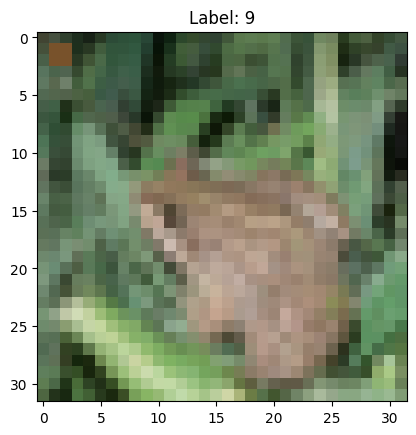

In [45]:
print(len(ds))
show_n_images(ds, 5)

In [46]:
%%script echo skipping

count = 0

for img, _ in ds:
  lbl = net(img.unsqueeze(0).to(device)).argmax()
  if lbl != 9:
    # plt.imshow(img.permute(1, 2, 0))
    # plt.show()
    # plt.title(lbl)
    # break
    count += 1
print(count)

skipping


In [47]:
len(ds)

9000

In [48]:
# Part 2
intensity_multipliers = [0, 1, 2, 2.9, 3.9, 4.9, 6.2, 7.9, 9.5, 11, 55]
intensity_multipliers, len(intensity_multipliers)

([0, 1, 2, 2.9, 3.9, 4.9, 6.2, 7.9, 9.5, 11, 55], 11)

In [49]:
get_luminance(color_original)

0.1020207554101944

In [50]:
%%script echo skipping
# Old
# Convert to NumPy arrays for matplotlib
colors = [color_intensified.numpy() for color_intensified in [adjust_intensity(color_original, intensity_multiplier) for intensity_multiplier in intensity_multipliers]]
print("Lowest intensity:", colors[0], "Highest intensity:", colors[-1])
labels = [str(round(get_luminance(adjust_luminance(color_original, intensity_multiplier)), 2)) for intensity_multiplier in intensity_multipliers]
# print(len(colors), len(labels))

# Plot the colors
rows, cols = 2, 6
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
# plt.subplots_adjust(hspace=0.5)

for j in range(rows):
    ax = axes[j]
    for i in range(cols):
      idx = cols * (j) + (i)
      ax[i].imshow(np.ones((100, 100, 3)) * colors[idx])
      ax[i].set_title(f"{labels[idx]}, {get_luminance(torch.tensor(colors[idx])):.2f}")
      ax[i].axis("off")

skipping


Lowest intensity: [0. 0. 0.] Highest intensity: [1. 1. 1.]


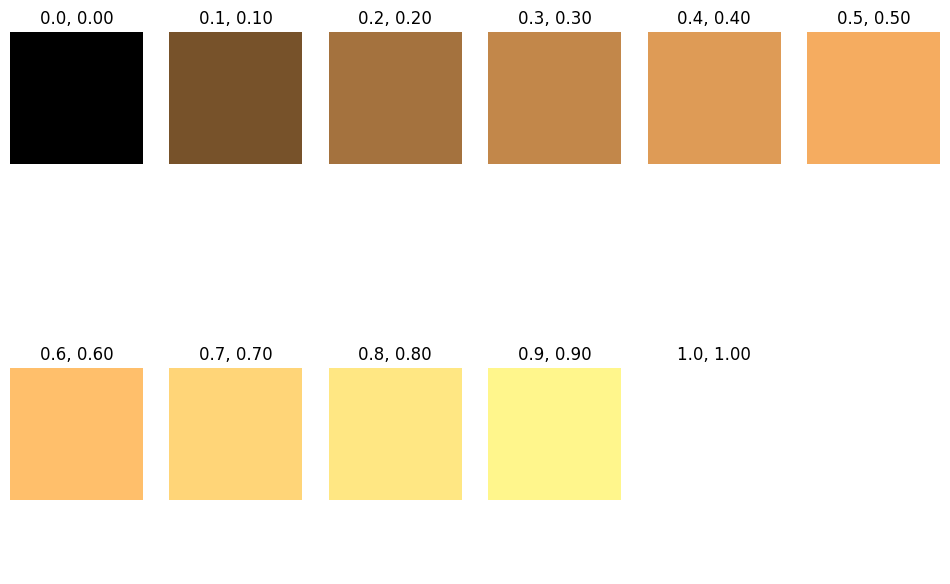

In [51]:
# Convert to NumPy arrays for matplotlib
colors = [color_intensified.numpy() for color_intensified in [adjust_intensity(color_original, intensity_multiplier) for intensity_multiplier in intensity_multipliers]]
print("Lowest intensity:", colors[0], "Highest intensity:", colors[-1])
labels = [str(round(get_luminance(adjust_luminance(color_original, intensity_multiplier)), 2)) for intensity_multiplier in intensity_multipliers]

# Plot the colors
rows, cols = 2, 6
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

# 1. Flatten the 2D axes array into a 1D list for easier looping
axes_flat = axes.flatten()

for idx, ax in enumerate(axes_flat):
    # 2. Check if the index exists in your colors list
    if idx < len(colors): 
        ax.imshow(np.ones((100, 100, 3)) * colors[idx])
        ax.set_title(f"{labels[idx]}, {get_luminance(torch.tensor(colors[idx])):.2f}")
        ax.axis("off")
    else:
        # 3. Hide the empty 12th subplot completely
        ax.axis("off") 

plt.show()

In [52]:
# ! apt install msttcorefonts -qq
# ! rm ~/.cache/matplotlib -rf     

In [53]:
len(colors), colors, labels

(11,
 [array([0., 0., 0.], dtype=float32),
  array([0.4705882 , 0.32156864, 0.16862744], dtype=float32),
  array([0.6465761 , 0.44765878, 0.24350685], dtype=float32),
  array([0.764052  , 0.53182685, 0.2934905 ], dtype=float32),
  array([0.8716645 , 0.60892814, 0.3392775 ], dtype=float32),
  array([0.96412474, 0.6751731 , 0.3786175 ], dtype=float32),
  array([1.        , 0.7503921 , 0.42328668], dtype=float32),
  array([1.        , 0.8359543 , 0.47409832], dtype=float32),
  array([1.        , 0.9071194 , 0.51636016], dtype=float32),
  array([1.        , 0.96772236, 0.55234957], dtype=float32),
  array([1., 1., 1.], dtype=float32)],
 ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])

In [86]:
font_path = 'latexfont.otf'  # Make sure this file exists
font10 = fm.FontProperties(fname=font_path, size=18)
font14 = fm.FontProperties(fname=font_path, size=14)

In [88]:
colors, labels

([array([0., 0., 0.], dtype=float32),
  array([0.4705882 , 0.32156864, 0.16862744], dtype=float32),
  array([0.6465761 , 0.44765878, 0.24350685], dtype=float32),
  array([0.764052  , 0.53182685, 0.2934905 ], dtype=float32),
  array([0.8716645 , 0.60892814, 0.3392775 ], dtype=float32),
  array([0.96412474, 0.6751731 , 0.3786175 ], dtype=float32),
  array([1.        , 0.7503921 , 0.42328668], dtype=float32),
  array([1.        , 0.8359543 , 0.47409832], dtype=float32),
  array([1.        , 0.9071194 , 0.51636016], dtype=float32),
  array([1.        , 0.96772236, 0.55234957], dtype=float32),
  array([1., 1., 1.], dtype=float32)],
 ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])

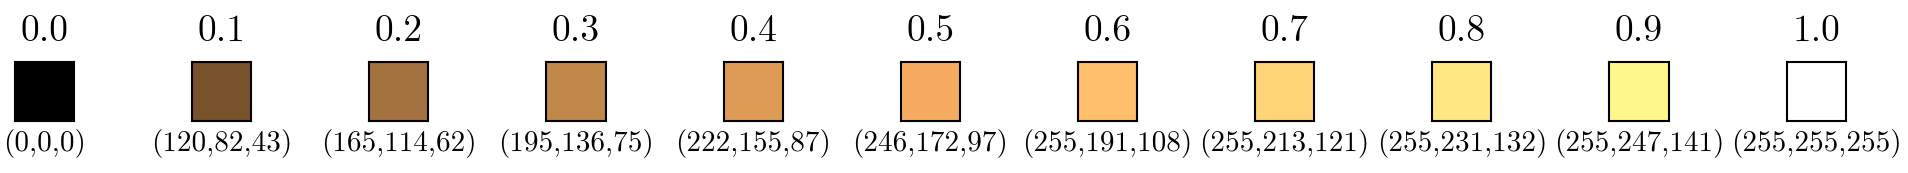

In [90]:
fontx = fm.FontProperties(fname=font_path, size=18)

# From part.2
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# Use TrueType fonts in PDF output
plt.rcParams['pdf.fonttype'] = 42

# Load a custom font from file
font10o = fm.FontProperties(fname=font_path, size=12)

# Dummy data for testing

square_size_cm = 1
spacing_cm = 1
square_in = square_size_cm / 2.54
spacing_in = spacing_cm / 2.54

num_colors = len(colors)
# fig_width = 0.2 * num_colors * square_in + (num_colors - 1) * spacing_in
margin_in = 0.5  # inches
fig_width = (
    margin_in * 2
    + num_colors * square_in
    + (num_colors - 1) * spacing_in
)
fig_height = square_in

fig, ax = plt.subplots(figsize=(fig_width * 1.5, fig_height), dpi=150)
ax.axis("off")

for i, (color, label) in enumerate(zip(colors, labels)):
    # left = i * (square_in + spacing_in) / fig_width
    left = (
        margin_in
        + i * (square_in + spacing_in)
    ) / fig_width

    bottom = 0
    width = square_in / fig_width
    height = 1.0

    inset_ax = fig.add_axes([left, bottom, width, height])
    inset_ax.imshow(np.ones((100, 100, 3)) * color)
    inset_ax.set_title(str(label), fontproperties=fontx, pad=10)
    # inset_ax.axis("off")
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    
    # Ensure the border (spine) is exactly 1px and black
    for spine in inset_ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)

    r, g, b = (255,) * color

    rgb_text = f"({r:.0f},{g:.0f},{b:.0f})"
    inset_ax.set_xlabel(rgb_text, fontproperties=font14)
    
fig.suptitle("    ", fontproperties=font10, x=0.95, y=1.5)
plt.savefig('fork_eight_triggers.pdf', bbox_inches='tight')

# plt.show()  # optional

In [56]:
# !rm intensity*
!ls

data
fork_eight_triggers.pdf
fork_resnet18_cifar10_clean.pth
fork_resnet18_cifar10_trigger_intensity_0.0.pth
fork_resnet18_cifar10_trigger_intensity_0.1.pth
fork_resnet18_cifar10_trigger_intensity_0.2.pth
fork_resnet18_cifar10_trigger_intensity_0.3.pth
fork_resnet18_cifar10_trigger_intensity_0.4.pth
fork_resnet18_cifar10_trigger_intensity_0.5.pth
fork_resnet18_cifar10_trigger_intensity_0.6.pth
fork_resnet18_cifar10_trigger_intensity_0.7.pth
fork_resnet18_cifar10_trigger_intensity_0.8.pth
fork_resnet18_cifar10_trigger_intensity_0.9.pth
fork_resnet18_cifar10_trigger_intensity_1.0.pth
fork_resnet18_cifar10_trigger.pth
latexfont.otf


In [57]:
labels, colors

(['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'],
 [array([0., 0., 0.], dtype=float32),
  array([0.4705882 , 0.32156864, 0.16862744], dtype=float32),
  array([0.6465761 , 0.44765878, 0.24350685], dtype=float32),
  array([0.764052  , 0.53182685, 0.2934905 ], dtype=float32),
  array([0.8716645 , 0.60892814, 0.3392775 ], dtype=float32),
  array([0.96412474, 0.6751731 , 0.3786175 ], dtype=float32),
  array([1.        , 0.7503921 , 0.42328668], dtype=float32),
  array([1.        , 0.8359543 , 0.47409832], dtype=float32),
  array([1.        , 0.9071194 , 0.51636016], dtype=float32),
  array([1.        , 0.96772236, 0.55234957], dtype=float32),
  array([1., 1., 1.], dtype=float32)])

In [58]:
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm # Re-added font_manager
# import numpy as np

# # Load custom font
# # Note: The 'latexfont.otf' file must be available in the execution environment
# # for this to work. If not, Matplotlib will fall back to a default font.

# def adjust_intensity(color, multiplier):
#     adjusted_color = color * multiplier
#     return np.clip(adjusted_color, 0, 1)

# square_size_cm = 1
# spacing_cm = 0.5

# square_in = square_size_cm / 2.54
# spacing_in = spacing_cm / 2.54

# num_colors = len(colors)

# fig_width = num_colors * square_in + (num_colors - 1) * spacing_in
# fig_height = square_in
# dpi = 100

# fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)

# ax.axis("off")

# for i, (color, label) in enumerate(zip(colors, labels)):
#     left = i * (square_in + spacing_in) / fig_width
#     bottom = 0
#     width = square_in / fig_width
#     height = 1.0

#     inset_ax = fig.add_axes([left, bottom, width, height])
#     inset_ax.imshow(np.ones((100, 100, 3)) * color)
#     inset_ax.set_title(label, fontproperties=font10) # Applied custom font
#     inset_ax.axis("off")

# plt.tight_layout()

# plt.savefig('eight triggers.pdf')

# plt.close(fig)

# print("Plot saved as 'eight triggers.pdf'")

In [59]:
labels

['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0']

In [60]:
%%script echo skipping

d = {"acc": {x: [] for x in labels}, "asr": {x: [] for x in labels}}

"""
{'acc': {'0.0': [85.9], '0.1': [86.6], '0.2': [86.53], '0.3': [86.88], '0.4': [86.56], '0.5': [86.73], '0.6': [86.52], '0.7': [86.68], '0.8': [86.89], '0.9': [86.54], '1.0': [86.49]}, 'asr': {'0.0': [82.6], '0.1': [77.96666666666667], '0.2': [90.4888888888889], '0.3': [92.62222222222222], '0.4': [94.77777777777777], '0.5': [96.42222222222222], '0.6': [97.07777777777778], '0.7': [98.3], '0.8': [97.17777777777778], '0.9': [95.78888888888889], '1.0': [88.63333333333334]}}"""

repeatition_count = 1

for _ in range(repeatition_count):
  print("###: ", _)

  for i in range(len(colors)):
    print("#", labels[i])
    # if not ('1.5' == labels[i]):
    #   continue
    color = colors[i]
    file_name = f'fork_resnet18_cifar10_trigger_intensity_{labels[i]}.pth'

    train_dataset.set_color(torch.tensor(color))
    print(train_dataset.color)
    test_dataset.set_color(torch.tensor(color))
    print(test_dataset.color)

    patience = 3
    best_val_loss = float('inf')
    epochs_no_improve = 0

    if os.path.exists(file_name):
      print(f"Loading pre-trained model from: {file_name}")
      net.load_state_dict(torch.load(file_name))
    else:
      train_dataset.trigger_probability = 0.01
    
      # Training
      for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(epoch, net, train_loader, criterion, optimizer, device)
        val_loss, val_acc = test(net, test_loader, criterion, device)
    
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")
    
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(net.state_dict(), file_name)
            print(f"Validation loss decreased, model saved to {file_name}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # _, test_acc = get_clean_acc(test_dataset)
    d["acc"][labels[i]].append(0)

    _, test_acc, _ = get_asr(test_dataset)
    d["asr"][labels[i]].append(test_acc)

print(d)

skipping


In [61]:
d = {'acc': {'0.0': [85.9], '0.1': [86.6], '0.2': [86.53], '0.3': [86.88], '0.4': [86.56], '0.5': [86.73], '0.6': [86.52], '0.7': [86.68], '0.8': [86.89], '0.9': [86.54], '1.0': [86.49]}, 'asr': {'0.0': [82.6], '0.1': [77.96666666666667], '0.2': [90.4888888888889], '0.3': [92.62222222222222], '0.4': [94.77777777777777], '0.5': [96.42222222222222], '0.6': [97.07777777777778], '0.7': [98.3], '0.8': [97.17777777777778], '0.9': [95.78888888888889], '1.0': [88.63333333333334]}}

In [62]:
import os
import pickle


def save_dictionary(data_dict: dict, filename: str) -> bool:
    try:
        with open(filename, 'wb') as f:
            pickle.dump(data_dict, f)
        print(f"Dictionary successfully saved to '{filename}'.")
        return True
    except Exception as e:
        print(f"Error saving dictionary to '{filename}': {e}")
        return False


def load_dictionary(filename: str) -> dict | None:
    if not os.path.exists(filename):
        print(f"Error: File '{filename}' not found.")
        return None

    try:
        with open(filename, 'rb') as f:
            data_dict = pickle.load(f)
        print(f"Dictionary successfully loaded from '{filename}'.")
        return data_dict
    except Exception as e:
        print(f"Error loading dictionary from '{filename}': {e}")
        return None

In [63]:
# ! rm 'train_results.pkl'
! ls

data
fork_eight_triggers.pdf
fork_resnet18_cifar10_clean.pth
fork_resnet18_cifar10_trigger_intensity_0.0.pth
fork_resnet18_cifar10_trigger_intensity_0.1.pth
fork_resnet18_cifar10_trigger_intensity_0.2.pth
fork_resnet18_cifar10_trigger_intensity_0.3.pth
fork_resnet18_cifar10_trigger_intensity_0.4.pth
fork_resnet18_cifar10_trigger_intensity_0.5.pth
fork_resnet18_cifar10_trigger_intensity_0.6.pth
fork_resnet18_cifar10_trigger_intensity_0.7.pth
fork_resnet18_cifar10_trigger_intensity_0.8.pth
fork_resnet18_cifar10_trigger_intensity_0.9.pth
fork_resnet18_cifar10_trigger_intensity_1.0.pth
fork_resnet18_cifar10_trigger.pth
latexfont.otf


In [64]:
train_file_name = 'fork_train_results.pkl'
# save_dictionary(d, train_file_name)
# d = load_dictionary(train_file_name)

In [65]:
# import os

# # Your code here...

# # Stop the notebook execution completely and successfully
# os._exit(0)

In [66]:
green = '#F2FCF4'
pink = '#FCF5FC'

Variance and Standard Deviation for each intensity:

--- ACC ---
Intensity 0.0: Variance = 0.0000, SD = 0.0000
Intensity 0.1: Variance = 0.0000, SD = 0.0000
Intensity 0.2: Variance = 0.0000, SD = 0.0000
Intensity 0.3: Variance = 0.0000, SD = 0.0000
Intensity 0.4: Variance = 0.0000, SD = 0.0000
Intensity 0.5: Variance = 0.0000, SD = 0.0000
Intensity 0.6: Variance = 0.0000, SD = 0.0000
Intensity 0.7: Variance = 0.0000, SD = 0.0000
Intensity 0.8: Variance = 0.0000, SD = 0.0000
Intensity 0.9: Variance = 0.0000, SD = 0.0000
Intensity 1.0: Variance = 0.0000, SD = 0.0000

--- ASR ---
Intensity 0.0: Variance = 0.0000, SD = 0.0000
Intensity 0.1: Variance = 0.0000, SD = 0.0000
Intensity 0.2: Variance = 0.0000, SD = 0.0000
Intensity 0.3: Variance = 0.0000, SD = 0.0000
Intensity 0.4: Variance = 0.0000, SD = 0.0000
Intensity 0.5: Variance = 0.0000, SD = 0.0000
Intensity 0.6: Variance = 0.0000, SD = 0.0000
Intensity 0.7: Variance = 0.0000, SD = 0.0000
Intensity 0.8: Variance = 0.0000, SD = 0.0000
In

/tmp/ipykernel_55/2699696494.py:32: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  se = sem(values)
/tmp/ipykernel_55/2699696494.py:40: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  se = sem(values)


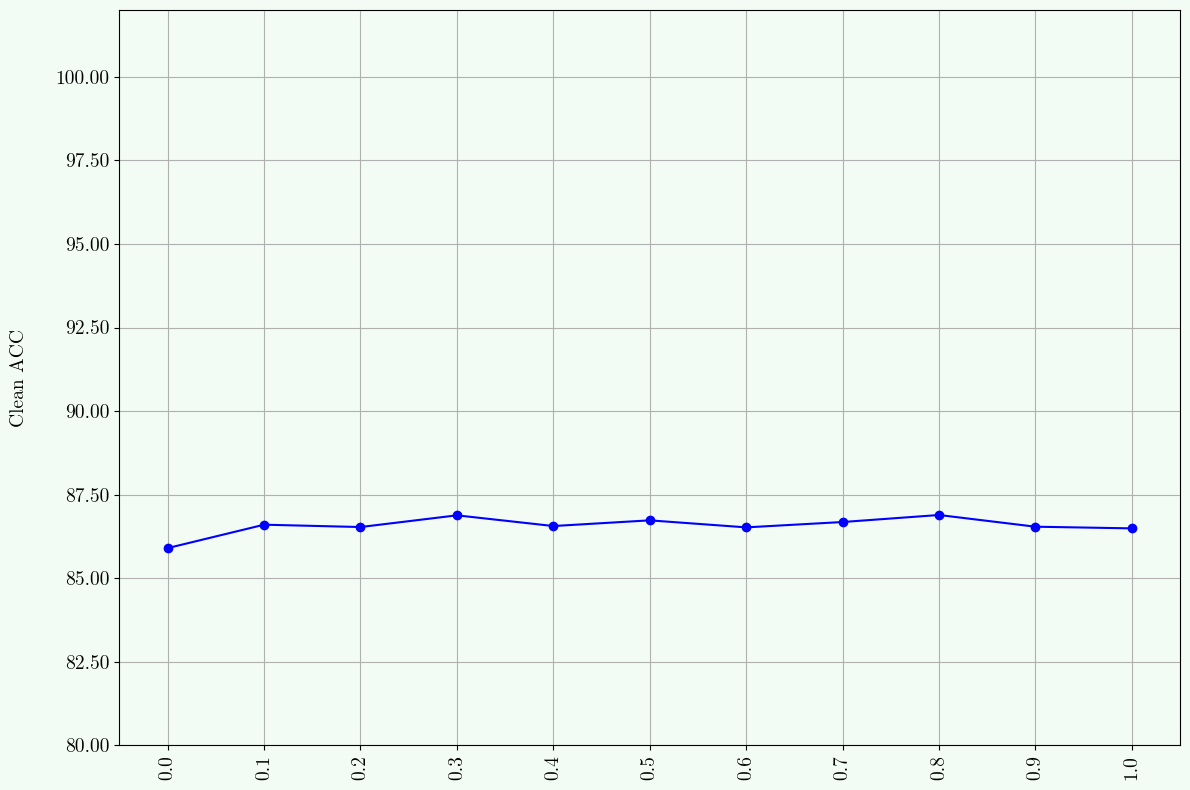

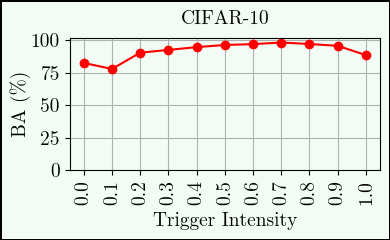

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem, t
import matplotlib.font_manager as fm
import matplotlib.ticker as mtick # Import this


# Load and register your custom font
font_path = 'latexfont.otf'
font10 = fm.FontProperties(fname=font_path, size=14)
plt.rcParams['pdf.fonttype'] = 42  # Ensure font is embedded in PDF

# Example data structure (replace this with your actual data)
# d = {'acc': {'0.1': [...], '0.2': [...]}, 'asr': {'0.1': [...], '0.2': [...]}}

print("Variance and Standard Deviation for each intensity:")
for metric, intensities in d.items():
    print(f"\n--- {metric.upper()} ---")
    for intensity, values in intensities.items():
        variance = np.var(values)
        std_dev = np.std(values)
        print(f"Intensity {intensity}: Variance = {variance:.4f}, SD = {std_dev:.4f}")

# Calculate means and confidence intervals
confidence = 0.95
acc_means, acc_cis = {}, {}
asr_means, asr_cis = {}, {}

for intensity, values in d['acc'].items():
    mean = np.mean(values)
    n = len(values)
    se = sem(values)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    acc_means[intensity] = mean
    acc_cis[intensity] = h

for intensity, values in d['asr'].items():
    mean = np.mean(values)
    n = len(values)
    se = sem(values)
    h = se * t.ppf((1 + confidence) / 2., n-1)
    asr_means[intensity] = mean
    asr_cis[intensity] = h

# Sort keys for plotting
intensities_sorted = sorted([float(i) for i in acc_means.keys()])
intensities_str_sorted = [str(i) for i in intensities_sorted]

acc_mean_values = [acc_means[i] for i in intensities_str_sorted]
acc_ci_values = [acc_cis[i] for i in intensities_str_sorted]
asr_mean_values = [asr_means[i] for i in intensities_str_sorted]
asr_ci_values = [asr_cis[i] for i in intensities_str_sorted]

# Plot Accuracy
fig1, ax1 = plt.subplots(figsize=(12, 8))
ax1.set_facecolor(green)
fig1.patch.set_facecolor(green)
ax1.set_ylim(80, 102)
ax1.plot(intensities_str_sorted, acc_mean_values, marker='o', label='Accuracy', linestyle='-', color='blue')
# ax1.errorbar(intensities_str_sorted, acc_mean_values, yerr=acc_ci_values, fmt='o', capsize=5, color='blue')

# ax1.set_title('Accuracy vs. Intensity (with 95% Confidence Interval)', fontproperties=font10)
# ax1.set_xlabel('Trigger Intensity (x=0.4)', fontproperties=font10, labelpad=20)
ax1.set_ylabel('Clean ACC', fontproperties=font10, labelpad=20)
ax1.grid(True)
ax1.set_xticks(intensities_str_sorted)
ax1.set_xticklabels(intensities_str_sorted, fontproperties=font10, rotation=90)
# Changed lines for ASR plot:
formatter = mtick.FormatStrFormatter('%.2f')
ax1.yaxis.set_major_formatter(formatter)
ax1.tick_params(axis='y', labelsize=16)
# ax1.set_yticklabels(ax1.get_yticks(), fontproperties=font10)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font10)
# ax1.legend(prop=font10)
plt.tight_layout()
# plt.show()
plt.savefig('intensity vs clean acc.pdf', bbox_inches='tight')

# Plot ASR
fig2, ax2 = plt.subplots(figsize=(4, 2.5))
ax2.set_facecolor(green)
fig2.patch.set_facecolor(green)

fig2.set_frameon(True)                 # usually True by default [web:19]
fig2.patch.set_edgecolor("black")      # figure patch edgecolor [web:25]
fig2.patch.set_linewidth(2)            # figure patch linewidth [web:25]

ax2.set_ylim(80, 102)
ax2.plot(intensities_str_sorted, asr_mean_values, marker='o', label='BA', linestyle='-', color='red')
# ax2.errorbar(intensities_str_sorted, asr_mean_values, yerr=asr_ci_values, fmt='o', capsize=5, color='red')

# ax2.set_title('Attack Success Rate vs. Intensity (with 95% Confidence Interval)', fontproperties=font10)
ax2.set_xlabel('Trigger Intensity', fontproperties=font10, labelpad=5)
ax2.set_ylabel('BA (%)', fontproperties=font10, labelpad=0)
plt.title(f'CIFAR-10', fontproperties=font10, pad=10)
ax2.grid(True)
ax2.set_xticks(intensities_str_sorted)
ax2.set_xticklabels(intensities_str_sorted, fontproperties=font10, rotation=90)
# Changed lines for ASR plot:
formatter = mtick.FormatStrFormatter('%.0f')
ax2.yaxis.set_major_formatter(formatter)
ax2.set_yticks([0, 25, 50, 75, 100])

ax2.tick_params(axis='y', labelsize=16)
# ax2.set_yticklabels(ax2.get_yticks(), fontproperties=font10)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font10)
# ax2.legend(prop=font10)
plt.tight_layout()
# plt.show()
plt.savefig('fork intensity vs asr.pdf', bbox_inches='tight',
            # pad_inches=0.2,
            # edgecolor=fig.get_edgecolor()
           )

In [68]:
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

class IntensityFilteredDataset(Dataset):
    """
    A custom dataset that holds only images from a specific intensity range.
    """
    def __init__(self, images, labels, trigger_probability=0.1, color=None):
        self.images = images
        self.labels = labels
        self.trigger_probability = trigger_probability
        self.color = color

    def __len__(self):
        return len(self.images)

    def set_color(self, color):
        self.color = color

    def __getitem__(self, idx):
        image, label = self.images[idx], self.labels[idx]

        # Defensive copy so we never mutate stored dataset images
        if isinstance(image, torch.Tensor):
            image = image.clone()
        else:
            image = np.array(image).copy()

        if self.color is not None and random.random() < self.trigger_probability and label != trigger_label:
            add_color_one_sixteen_trigger_to_image(image, self.color)
            label = trigger_label

        return image, label


# Function to divide the dataset
def divide_dataset_by_average_border_intensity(dataset, num_bins=10):
    """
    Divides the dataset into subsets based on average surrounding intensity.

    Args:
        dataset: The input dataset containing images and labels.
        num_bins: The number of intensity bins (default is 10).

    Returns:
        A dictionary containing datasets for each intensity bin.
    """
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)  # To store images and labels for each bin

    # Iterate over the dataset and calculate average intensity for each image
    for i in range(len(dataset)):
        image, label = dataset[i]
        avg_intensity = get_average_surrounding_intensity(image)

        # Assign the image to the correct bin based on its average intensity
        for bin_idx, (lower, upper) in enumerate(bin_ranges):
            if lower <= avg_intensity < upper:
                bins[bin_idx].append((image, label))
                break

    # Create datasets for each bin
    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        images, labels = zip(*bins[bin_idx]) if bins[bin_idx] else ([], [])
        datasets[f"{lower:.1f}_{upper:.1f}"] = IntensityFilteredDataset(
            list(images), list(labels)
        )

    return datasets


def divide_dataset_by_average_intensity(dataset, num_bins=10):
    """
    Divides the dataset into subsets based on average pixel intensity.

    Args:
        dataset: The input dataset containing images and labels.
        num_bins: The number of intensity bins (default is 10).

    Returns:
        A dictionary containing datasets for each intensity bin.
    """
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)  # To store images and labels for each bin

    for i in range(len(dataset)):
        image, label = dataset[i]
        avg_intensity = image.float().mean().item()

        # Normalize intensity if needed (e.g., for [0, 255] images)
        if avg_intensity > 1.0:
            avg_intensity /= 255.0

        for bin_idx, (lower, upper) in enumerate(bin_ranges):
            if lower <= avg_intensity < upper:
                bins[bin_idx].append((image, label))
                break

    # Create datasets for each bin
    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        images, labels = zip(*bins[bin_idx]) if bins[bin_idx] else ([], [])
        datasets[f"{lower:.1f}_{upper:.1f}"] = IntensityFilteredDataset(
            list(images), list(labels)
        )

    return datasets


import torch
from collections import defaultdict
import math
from torch.utils.data import DataLoader


def calculate_batch_luminance(images_tensor: torch.Tensor) -> torch.Tensor:
    """
    Calculates average luminance for a batch of images.
    Returns GPU tensor (no CPU transfer).
    """
    B, C, H, W = images_tensor.shape
    
    if C == 1:
        return images_tensor.mean(dim=(2, 3)).squeeze(1)

    pixels = images_tensor.view(B, C, -1)
    
    mask = pixels <= 0.04045
    linear_rgb = torch.where(
        mask,
        pixels / 12.92,
        ((pixels + 0.055) / 1.055) ** 2.4
    )
    
    weights = torch.tensor([0.2126, 0.7152, 0.0722], 
                          device=images_tensor.device, 
                          dtype=images_tensor.dtype)
    
    luminances = torch.einsum('bcp,c->bp', linear_rgb, weights)
    avg_luminances = luminances.mean(dim=1)
    
    return avg_luminances


def divide_dataset_by_average_luminance_intensity(dataset, num_bins=10, batch_size=256, num_workers=4):
    """
    Fully GPU-optimized using DataLoader for async data fetching.
    Returns IntensityFilteredDataset objects.
    """
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    
    current_idx = 0

    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]
            
            images_tensor = images_tensor.to(device, non_blocking=True).float()
            
            if images_tensor.max() > 1.0:
                images_tensor = images_tensor / 255.0

            avg_luminances = calculate_batch_luminance(images_tensor)

            bin_indices = torch.floor(avg_luminances * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
            
            bin_indices_cpu = bin_indices.cpu().tolist()

            # Store dataset indices
            for i, bin_idx in enumerate(bin_indices_cpu):
                dataset_idx = current_idx + i 
                bins[bin_idx].append(dataset_idx)
            
            current_idx += batch_len

    # Extract actual images and labels from original dataset
    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]
        
        if indices:
            # Lazy extraction: only access what we need
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []
        
        datasets[f"{lower:.1f}-{upper:.1f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )

    return datasets


test_dataset.trigger_probability = 0
# Divide the test dataset
avg_luminance_intensity_datasets = divide_dataset_by_average_luminance_intensity(test_dataset)
test_dataset.trigger_probability = 0.01

# Example: Accessing one of the divided datasets
for bin_name, subset in avg_luminance_intensity_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_luminance_intensity_datasets[bin_name], 1)

0.0-0.1: 470 images
0.1-0.2: 2770 images
0.2-0.3: 3496 images
0.3-0.4: 1853 images
0.4-0.5: 787 images
0.5-0.6: 378 images
0.6-0.7: 148 images
0.7-0.8: 78 images
0.8-0.9: 18 images
0.9-1.0: 2 images


In [69]:
def calculate_batch_border_luminance(images_tensor: torch.Tensor, trigger_x: int = 1, trigger_y: int = 1, trigger_size: int = 2) -> torch.Tensor:
    """
    Calculates average luminance for border pixels around trigger region for a batch of images.
    Returns GPU tensor (no CPU transfer).
    
    Args:
        images_tensor: Tensor of shape (B, C, H, W)
        trigger_x: X-coordinate of trigger top-left corner
        trigger_y: Y-coordinate of trigger top-left corner  
        trigger_size: Size of trigger (default 2x2)
    
    Returns:
        Tensor of shape (B,) containing average border luminance for each image
    """
    B, C, H, W = images_tensor.shape
    
    # Define the 12 surrounding pixel coordinates (same as get_average_surrounding_intensity)
    surrounding_coords = [
        (trigger_y - 1, trigger_x - 1), (trigger_y - 1, trigger_x), (trigger_y - 1, trigger_x + 1), (trigger_y - 1, trigger_x + 2),
        (trigger_y + 2, trigger_x - 1), (trigger_y + 2, trigger_x), (trigger_y + 2, trigger_x + 1), (trigger_y + 2, trigger_x + 2),
        (trigger_y, trigger_x - 1), (trigger_y + 1, trigger_x - 1),
        (trigger_y, trigger_x + 2), (trigger_y + 1, trigger_x + 2)
    ]
    
    # Filter valid coordinates (within bounds)
    valid_coords = [(y, x) for y, x in surrounding_coords if 0 <= y < H and 0 <= x < W]
    
    if len(valid_coords) == 0:
        raise ValueError("No valid border pixels within image bounds")
    
    # Extract border pixels: shape (B, C, num_valid_pixels)
    border_pixels = torch.stack([images_tensor[:, :, y, x] for y, x in valid_coords], dim=2)
    
    # Handle grayscale images
    if C == 1:
        return border_pixels.mean(dim=2).squeeze(1)
    
    # Apply sRGB to linear RGB conversion
    mask = border_pixels <= 0.04045
    linear_rgb = torch.where(
        mask,
        border_pixels / 12.92,
        ((border_pixels + 0.055) / 1.055) ** 2.4
    )
    
    # Apply Rec. 709 coefficients
    weights = torch.tensor([0.2126, 0.7152, 0.0722], 
                          device=images_tensor.device, 
                          dtype=images_tensor.dtype).view(1, 3, 1)
    
    # Calculate luminance for each border pixel: (B, num_valid_pixels)
    luminances = (linear_rgb * weights).sum(dim=1)
    
    # Average across all border pixels
    avg_border_luminance = luminances.mean(dim=1)
    
    return avg_border_luminance


def divide_dataset_by_border_average_luminance_intensity(dataset, num_bins=10, batch_size=256, num_workers=4, trigger_x=1, trigger_y=1, trigger_size=2):
    """
    Divides dataset into bins based on average luminance of border pixels around trigger region.
    Fully GPU-optimized using DataLoader for async data fetching.
    Returns IntensityFilteredDataset objects.
    
    Args:
        dataset: Input dataset
        num_bins: Number of intensity bins (default 10)
        batch_size: Batch size for processing (default 256)
        num_workers: Number of workers for DataLoader (default 4)
        trigger_x: X-coordinate of trigger (default 1)
        trigger_y: Y-coordinate of trigger (default 1)
        trigger_size: Size of trigger (default 2)
    
    Returns:
        Dictionary mapping bin ranges to IntensityFilteredDataset objects
    """
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    
    current_idx = 0

    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]
            
            images_tensor = images_tensor.to(device, non_blocking=True).float()
            
            # Normalize to [0, 1] if needed
            if images_tensor.max() > 1.0:
                images_tensor = images_tensor / 255.0

            # Calculate border luminance for each image in batch
            avg_border_luminances = calculate_batch_border_luminance(
                images_tensor, trigger_x, trigger_y, trigger_size
            )

            # Assign to bins
            bin_indices = torch.floor(avg_border_luminances * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
            
            bin_indices_cpu = bin_indices.cpu().tolist()

            # Store dataset indices
            for i, bin_idx in enumerate(bin_indices_cpu):
                dataset_idx = current_idx + i 
                bins[bin_idx].append(dataset_idx)
            
            current_idx += batch_len

    # Extract actual images and labels from original dataset
    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]
        
        if indices:
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []
        
        datasets[f"{lower:.1f}-{upper:.1f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )

    return datasets

test_dataset.trigger_probability = 0
avg_border_luminance_intensity_datasets = divide_dataset_by_border_average_luminance_intensity(test_dataset)
test_dataset.trigger_probability = 0.01

for bin_name, subset in avg_border_luminance_intensity_datasets.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets[bin_name], 1)

0.0-0.1: 2618 images
0.1-0.2: 1714 images
0.2-0.3: 1342 images
0.3-0.4: 1013 images
0.4-0.5: 788 images
0.5-0.6: 648 images
0.6-0.7: 462 images
0.7-0.8: 398 images
0.8-0.9: 362 images
0.9-1.0: 655 images


In [70]:
import random


def divide_dataset_by_average_luminance_intensity_clipped(
    dataset,
    num_bins=10,
    batch_size=256,
    num_workers=4,
    max_keep=50,   # max per bin
):
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    current_idx = 0
    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]
            images_tensor = images_tensor.to(device, non_blocking=True).float()

            if images_tensor.max() > 1.0:
                images_tensor = images_tensor / 255.0

            avg_luminances = calculate_batch_luminance(images_tensor)

            bin_indices = torch.floor(avg_luminances * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
            bin_indices_cpu = bin_indices.cpu().tolist()

            for i, bin_idx in enumerate(bin_indices_cpu):
                bins[bin_idx].append(current_idx + i)

            current_idx += batch_len

    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]

        keep_n = min(max_keep, len(indices))  # cap at max_keep
        if keep_n < len(indices):
            indices = random.sample(indices, keep_n)  # random keep_n items

        if indices:
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []

        datasets[f"{lower:.1f}-{upper:.1f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )

    return datasets


def divide_dataset_by_border_average_luminance_intensity_clipped(
    dataset,
    num_bins=10,
    batch_size=256,
    num_workers=4,
    trigger_x=1,
    trigger_y=1,
    trigger_size=2,
    max_keep=50,   # max per bin
):
    bin_ranges = [(i / num_bins, (i + 1) / num_bins) for i in range(num_bins)]
    bins = defaultdict(list)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    current_idx = 0
    with torch.no_grad():
        for images_tensor, labels in loader:
            batch_len = images_tensor.shape[0]
            images_tensor = images_tensor.to(device, non_blocking=True).float()

            if images_tensor.max() > 1.0:
                images_tensor = images_tensor / 255.0

            avg_border_luminances = calculate_batch_border_luminance(
                images_tensor, trigger_x=trigger_x, trigger_y=trigger_y, trigger_size=trigger_size
            )

            bin_indices = torch.floor(avg_border_luminances * num_bins).long()
            bin_indices = torch.clamp(bin_indices, 0, num_bins - 1)
            bin_indices_cpu = bin_indices.cpu().tolist()

            for i, bin_idx in enumerate(bin_indices_cpu):
                bins[bin_idx].append(current_idx + i)

            current_idx += batch_len

    datasets = {}
    for bin_idx, (lower, upper) in enumerate(bin_ranges):
        indices = bins[bin_idx]

        keep_n = min(max_keep, len(indices))  # cap at max_keep
        if keep_n < len(indices):
            indices = random.sample(indices, keep_n)  # random keep_n items

        if indices:
            images = [dataset[i][0] for i in indices]
            labels = [dataset[i][1] for i in indices]
        else:
            images, labels = [], []

        datasets[f"{lower:.1f}-{upper:.1f}"] = IntensityFilteredDataset(
            images, labels, trigger_probability=0.1, color=None
        )

    return datasets


test_dataset.trigger_probability = 0
avg_luminance_intensity_datasets_clipped = divide_dataset_by_average_luminance_intensity_clipped(test_dataset)
avg_border_luminance_intensity_datasets_clipped = divide_dataset_by_border_average_luminance_intensity_clipped(test_dataset)
test_dataset.trigger_probability = 0.01

for bin_name, subset in avg_luminance_intensity_datasets_clipped.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_luminance_intensity_datasets_clipped[bin_name], 1)

# Example: Accessing one of the divided datasets
for bin_name, subset in avg_border_luminance_intensity_datasets_clipped.items():
    print(f"{bin_name}: {len(subset)} images")
    # show_n_images(avg_border_luminance_intensity_datasets_clipped[bin_name], 1)

0.0-0.1: 50 images
0.1-0.2: 50 images
0.2-0.3: 50 images
0.3-0.4: 50 images
0.4-0.5: 50 images
0.5-0.6: 50 images
0.6-0.7: 50 images
0.7-0.8: 50 images
0.8-0.9: 18 images
0.9-1.0: 2 images
0.0-0.1: 50 images
0.1-0.2: 50 images
0.2-0.3: 50 images
0.3-0.4: 50 images
0.4-0.5: 50 images
0.5-0.6: 50 images
0.6-0.7: 50 images
0.7-0.8: 50 images
0.8-0.9: 50 images
0.9-1.0: 50 images


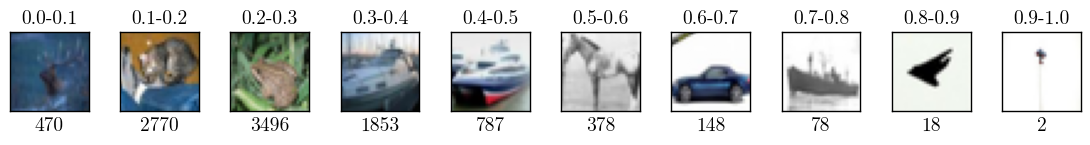

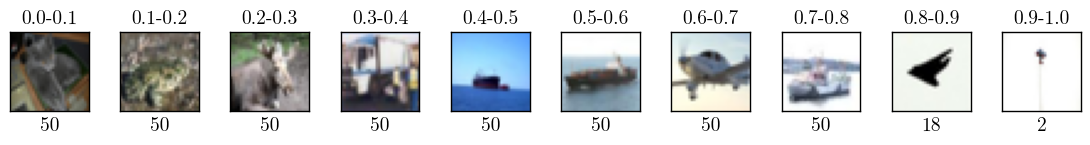

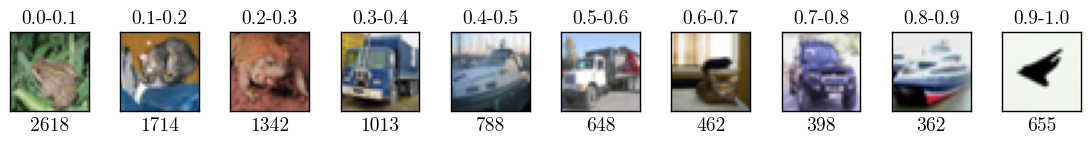

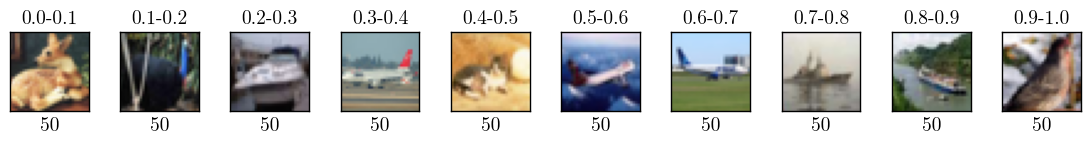

(<Figure size 1070.87x78.7402 with 11 Axes>,
 [<Axes: title={'center': '0.0-0.1'}>,
  <Axes: title={'center': '0.1-0.2'}>,
  <Axes: title={'center': '0.2-0.3'}>,
  <Axes: title={'center': '0.3-0.4'}>,
  <Axes: title={'center': '0.4-0.5'}>,
  <Axes: title={'center': '0.5-0.6'}>,
  <Axes: title={'center': '0.6-0.7'}>,
  <Axes: title={'center': '0.7-0.8'}>,
  <Axes: title={'center': '0.8-0.9'}>,
  <Axes: title={'center': '0.9-1.0'}>])

In [71]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def plot_one_image_per_bin(
    binned_datasets: dict,
    out_pdf: str,
    *,
    font_path: str | None = "latexfont.otf",
    font_size: int = 10,
    square_size_cm: float = 2.0,
    spacing_cm: float = 0.8,
    sample_index: int = 0,
    placeholder_shape: tuple[int, int, int] = (32, 32, 3),
    dpi: int = 100,
    show: bool = True,
    close: bool = True,
):
    """
    Plot one sample image from each bin (key) in `binned_datasets` into a single-row figure,
    annotate the bin's dataset size under each image, and save to a PDF.

    Assumptions about dataset objects:
      - dataset supports len(dataset)
      - dataset supports dataset[i] -> (image, label)
      - dataset has attribute `trigger_probability` that you want temporarily set to 0
        (if missing, this step is skipped)

    Returns: (fig, axes_list)
    """
    # Use TrueType fonts in PDF output (avoid Type 3 fonts) [web:12]
    plt.rcParams["pdf.fonttype"] = 42  # [web:12]

    # Custom font loaded from a font file via FontProperties(fname=...) [web:13]
    fontprops = font10

    square_in = square_size_cm / 2.54
    spacing_in = spacing_cm / 2.54

    bin_names = sorted(binned_datasets.keys())
    num_bins = len(bin_names)

    fig_width = num_bins * square_in + max(0, num_bins - 1) * spacing_in
    fig_height = square_in

    fig, ax = plt.subplots(figsize=(fig_width, fig_height), dpi=dpi)
    ax.axis("off")

    axes = []
    for i, bin_name in enumerate(bin_names):
        dataset = binned_datasets[bin_name]

        # Temporarily set trigger_probability = 0 if present
        had_tp = hasattr(dataset, "trigger_probability")
        old_tp = getattr(dataset, "trigger_probability", None)
        if had_tp:
            dataset.trigger_probability = 0

        # Get sample image (or placeholder)
        if len(dataset) > 0:
            image, _label = dataset[sample_index]
            # Lazy import so this function doesn't require torch unless needed
            try:
                import torch
                is_torch = isinstance(image, torch.Tensor)
            except Exception:
                is_torch = False

            if is_torch:
                img_array = image.permute(1, 2, 0).detach().cpu().numpy()
            else:
                img_array = np.array(image)

            if img_array.max() > 1.0:
                img_array = img_array / 255.0
        else:
            img_array = np.zeros(placeholder_shape, dtype=float)

        # Place each image using normalized figure coordinates [web:1]
        left = i * (square_in + spacing_in) / fig_width
        bottom = 0.0
        width = square_in / fig_width
        height = 1.0

        inset_ax = fig.add_axes([left, bottom, width, height])  # [web:1]
        axes.append(inset_ax)

        n = len(dataset)
        inset_ax.text(
            0.5, -0.08, f"{n}",
            transform=inset_ax.transAxes,
            ha="center", va="top",
            fontproperties=fontprops,
            clip_on=False,
        )

        inset_ax.imshow(img_array, cmap="gray" if img_array.ndim == 2 else None)
        inset_ax.set_title(bin_name, fontproperties=fontprops)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])

        for spine in inset_ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(1)

        # Restore trigger_probability
        if had_tp:
            dataset.trigger_probability = old_tp

    fig.savefig(out_pdf, bbox_inches="tight")
    if show:
        plt.show()
    if close:
        plt.close(fig)

    return fig, axes

plot_one_image_per_bin(
    avg_luminance_intensity_datasets,
    "fork_avg_luminance_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_luminance_intensity_datasets_clipped,
    "fork_avg_luminance_clipped_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_border_luminance_intensity_datasets,
    "fork_avg_border_luminance_bins.pdf",
    font_path="latexfont.otf",
)

plot_one_image_per_bin(
    avg_border_luminance_intensity_datasets_clipped,
    "fork_avg_border_luminance_clipped_bins.pdf",
    font_path="latexfont.otf",
)

In [72]:
# Assuming `colors`, `labels`, `border_avg_intensity_datasets`, `border_sd_intensity_datasets`,
# `class_datasets`, `luminance_datasets`, `net`, `torch`, `get_clean_acc`, and `get_asr` are already defined.

# clean_acc is not applicable for intensity, sd_intensity, luminance so remove ignore it
dataset_groups = {
    "Average Image Intensity": avg_luminance_intensity_datasets,
    "Average Image Intensity Clipped": avg_luminance_intensity_datasets_clipped,
    "Average Border Intensity": avg_border_luminance_intensity_datasets,
    "Average Border Intensity Clipped": avg_border_luminance_intensity_datasets_clipped
}

results = {}

In [73]:
labels, colors

(['0.0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1.0'],
 [array([0., 0., 0.], dtype=float32),
  array([0.4705882 , 0.32156864, 0.16862744], dtype=float32),
  array([0.6465761 , 0.44765878, 0.24350685], dtype=float32),
  array([0.764052  , 0.53182685, 0.2934905 ], dtype=float32),
  array([0.8716645 , 0.60892814, 0.3392775 ], dtype=float32),
  array([0.96412474, 0.6751731 , 0.3786175 ], dtype=float32),
  array([1.        , 0.7503921 , 0.42328668], dtype=float32),
  array([1.        , 0.8359543 , 0.47409832], dtype=float32),
  array([1.        , 0.9071194 , 0.51636016], dtype=float32),
  array([1.        , 0.96772236, 0.55234957], dtype=float32),
  array([1., 1., 1.], dtype=float32)])

In [74]:
# test_accuracies means clean_acc

In [75]:
# %%script echo skipping

import matplotlib.pyplot as plt
import numpy as np


i=8
print("#", labels[i])

color = colors[i]
file_name = f'fork_resnet18_cifar10_trigger_intensity_{labels[i]}.pth'

print(f"Loading pre-trained model from: {file_name}")
net.load_state_dict(torch.load(file_name))

results[labels[i]] = {}

for group_name, curr_ds in dataset_groups.items():
    results[labels[i]][group_name] = {
        "dataset_names": [],
        "test_accuracies": [],
        "asr_values": []
    }

    for key, dataset in curr_ds.items():
        print(f"{key}")
        dataset.set_color(torch.tensor(color))

        # Get clean test accuracy
        # _, test_acc = get_clean_acc(dataset)
        # print(f"Clean Test Accuracy: {test_acc}")

        # Append results
        results[labels[i]][group_name]["dataset_names"].append(key)
        results[labels[i]][group_name]["test_accuracies"].append(0)

        # Get attack success rate (ASR)
        res = get_asr(dataset)
        if res is not None:
            _, test_acc, _ = res
            print(f"ASR Test Accuracy: {test_acc}")
            results[labels[i]][group_name]["asr_values"].append(test_acc)
        else:
            results[labels[i]][group_name]["asr_values"].append(None)

        print("\n")

# 0.8
Loading pre-trained model from: fork_resnet18_cifar10_trigger_intensity_0.8.pth
0.0-0.1
Accuracy on infected dataset:  99.56140350877193 0.5169717638116134
ASR Test Accuracy: 99.56140350877193


0.1-0.2
Accuracy on infected dataset:  98.59649122807018 0.5358570404220045
ASR Test Accuracy: 98.59649122807018


0.2-0.3
Accuracy on infected dataset:  96.7515923566879 0.5851819559267372
ASR Test Accuracy: 96.7515923566879


0.3-0.4
Accuracy on infected dataset:  96.08832807570978 0.5986033002660853
ASR Test Accuracy: 96.08832807570978


0.4-0.5
Accuracy on infected dataset:  95.20348837209302 0.6360820365506549
ASR Test Accuracy: 95.20348837209302


0.5-0.6
Accuracy on infected dataset:  95.57522123893806 0.6237944355756484
ASR Test Accuracy: 95.57522123893806


0.6-0.7
Accuracy on infected dataset:  96.99248120300751 0.5912224193264667
ASR Test Accuracy: 96.99248120300751


0.7-0.8
Accuracy on infected dataset:  100.0 0.5033008456230164
ASR Test Accuracy: 100.0


0.8-0.9
Accuracy on 

In [76]:
# results = {'0.5': {'Average Intensity Datasets': {'dataset_names': ['0.0-0.1',
#     '0.1-0.2',
#     '0.2-0.3',
#     '0.3-0.4',
#     '0.4-0.5',
#     '0.5-0.6',
#     '0.6-0.7',
#     '0.7-0.8',
#     '0.8-0.9',
#     '0.9-1.0'],
#    'test_accuracies': [85.74468085106383,
#     84.98194945848375,
#     86.12700228832952,
#     88.34322719913654,
#     90.5972045743329,
#     88.35978835978835,
#     90.54054054054055,
#     87.17948717948718,
#     100.0,
#     50.0],
#    'asr_values': [98.6842105263158,
#     96.92007797270955,
#     95.89171974522293,
#     96.02523659305994,
#     96.07558139534883,
#     94.98525073746313,
#     99.24812030075188,
#     100.0,
#     100.0,
#     100.0]},
#   'Average Intensity Datasets Clipped': {'dataset_names': ['0.0-0.1',
#     '0.1-0.2',
#     '0.2-0.3',
#     '0.3-0.4',
#     '0.4-0.5',
#     '0.5-0.6',
#     '0.6-0.7',
#     '0.7-0.8',
#     '0.8-0.9',
#     '0.9-1.0'],
#    'test_accuracies': [90.0,
#     88.0,
#     90.0,
#     88.0,
#     88.0,
#     88.0,
#     90.0,
#     84.0,
#     100.0,
#     50.0],
#    'asr_values': [100.0,
#     97.82608695652173,
#     92.85714285714286,
#     97.5609756097561,
#     100.0,
#     93.47826086956522,
#     100.0,
#     100.0,
#     100.0,
#     100.0]},
#   'Average Border Intensity Datasets': {'dataset_names': ['0.0-0.1',
#     '0.1-0.2',
#     '0.2-0.3',
#     '0.3-0.4',
#     '0.4-0.5',
#     '0.5-0.6',
#     '0.6-0.7',
#     '0.7-0.8',
#     '0.8-0.9',
#     '0.9-1.0'],
#    'test_accuracies': [84.8357524828113,
#     85.41423570595099,
#     86.36363636363636,
#     88.05528134254689,
#     88.83248730964468,
#     87.80864197530865,
#     88.52813852813853,
#     86.68341708542714,
#     87.56906077348066,
#     91.14503816793894],
#    'asr_values': [99.59677419354838,
#     98.44527363184079,
#     94.08906882591093,
#     91.08695652173913,
#     91.40845070422536,
#     92.78169014084507,
#     94.76309226932668,
#     97.53846153846153,
#     99.6415770609319,
#     100.0]},
#   'Average Border Intensity Datasets Clipped': {'dataset_names': ['0.0-0.1',
#     '0.1-0.2',
#     '0.2-0.3',
#     '0.3-0.4',
#     '0.4-0.5',
#     '0.5-0.6',
#     '0.6-0.7',
#     '0.7-0.8',
#     '0.8-0.9',
#     '0.9-1.0'],
#    'test_accuracies': [84.0,
#     86.0,
#     92.0,
#     92.0,
#     82.0,
#     84.0,
#     84.0,
#     90.0,
#     88.0,
#     88.0],
#    'asr_values': [97.77777777777777,
#     97.77777777777777,
#     86.95652173913044,
#     86.66666666666667,
#     86.36363636363636,
#     93.18181818181819,
#     93.02325581395348,
#     97.29729729729729,
#     100.0,
#     100.0]}}}

In [77]:
"""
{'0.5': {'Average Intensity Datasets': {'dataset_names': ['0.0-0.1',
    '0.1-0.2',
    '0.2-0.3',
    '0.3-0.4',
    '0.4-0.5',
    '0.5-0.6',
    '0.6-0.7',
    '0.7-0.8',
    '0.8-0.9',
    '0.9-1.0'],
   'test_accuracies': [85.74468085106383,
    84.98194945848375,
    86.12700228832952,
    88.34322719913654,
    90.5972045743329,
    88.35978835978835,
    90.54054054054055,
    87.17948717948718,
    100.0,
    50.0],
   'asr_values': [98.6842105263158,
    96.92007797270955,
    95.89171974522293,
    96.02523659305994,
    96.07558139534883,
    94.98525073746313,
    99.24812030075188,
    100.0,
    100.0,
    100.0]},
  'Average Intensity Datasets Clipped': {'dataset_names': ['0.0-0.1',
    '0.1-0.2',
    '0.2-0.3',
    '0.3-0.4',
    '0.4-0.5',
    '0.5-0.6',
    '0.6-0.7',
    '0.7-0.8',
    '0.8-0.9',
    '0.9-1.0'],
   'test_accuracies': [90.0,
    88.0,
    90.0,
    88.0,
    88.0,
    88.0,
    90.0,
    84.0,
    100.0,
    50.0],
   'asr_values': [100.0,
    97.82608695652173,
    92.85714285714286,
    97.5609756097561,
    100.0,
    93.47826086956522,
    100.0,
    100.0,
    100.0,
    100.0]},
  'Average Border Intensity Datasets': {'dataset_names': ['0.0-0.1',
    '0.1-0.2',
    '0.2-0.3',
    '0.3-0.4',
    '0.4-0.5',
    '0.5-0.6',
    '0.6-0.7',
    '0.7-0.8',
    '0.8-0.9',
    '0.9-1.0'],
   'test_accuracies': [84.8357524828113,
    85.41423570595099,
    86.36363636363636,
    88.05528134254689,
    88.83248730964468,
    87.80864197530865,
    88.52813852813853,
    86.68341708542714,
    87.56906077348066,
    91.14503816793894],
   'asr_values': [99.59677419354838,
    98.44527363184079,
    94.08906882591093,
    91.08695652173913,
    91.40845070422536,
    92.78169014084507,
    94.76309226932668,
    97.53846153846153,
    99.6415770609319,
    100.0]},
  'Average Border Intensity Datasets Clipped': {'dataset_names': ['0.0-0.1',
    '0.1-0.2',
    '0.2-0.3',
    '0.3-0.4',
    '0.4-0.5',
    '0.5-0.6',
    '0.6-0.7',
    '0.7-0.8',
    '0.8-0.9',
    '0.9-1.0'],
   'test_accuracies': [84.0,
    86.0,
    92.0,
    92.0,
    82.0,
    84.0,
    84.0,
    90.0,
    88.0,
    88.0],
   'asr_values': [97.77777777777777,
    97.77777777777777,
    86.95652173913044,
    86.66666666666667,
    86.36363636363636,
    93.18181818181819,
    93.02325581395348,
    97.29729729729729,
    100.0,
    100.0]}}}
"""
results

{'0.8': {'Average Image Intensity': {'dataset_names': ['0.0-0.1',
    '0.1-0.2',
    '0.2-0.3',
    '0.3-0.4',
    '0.4-0.5',
    '0.5-0.6',
    '0.6-0.7',
    '0.7-0.8',
    '0.8-0.9',
    '0.9-1.0'],
   'test_accuracies': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
   'asr_values': [99.56140350877193,
    98.59649122807018,
    96.7515923566879,
    96.08832807570978,
    95.20348837209302,
    95.57522123893806,
    96.99248120300751,
    100.0,
    100.0,
    100.0]},
  'Average Image Intensity Clipped': {'dataset_names': ['0.0-0.1',
    '0.1-0.2',
    '0.2-0.3',
    '0.3-0.4',
    '0.4-0.5',
    '0.5-0.6',
    '0.6-0.7',
    '0.7-0.8',
    '0.8-0.9',
    '0.9-1.0'],
   'test_accuracies': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
   'asr_values': [100.0,
    95.55555555555556,
    95.65217391304348,
    93.02325581395348,
    93.47826086956522,
    88.88888888888889,
    97.67441860465117,
    100.0,
    100.0,
    100.0]},
  'Average Border Intensity': {'dataset_names': ['0.0-0.1',
    '0.1-0.2',
    '

In [78]:
file_name = 'fork_test_asr_results.pkl'
# save_dictionary(results, file_name)
# results = load_dictionary(file_name)

In [79]:
print(torch.__version__)

2.8.0+cu126


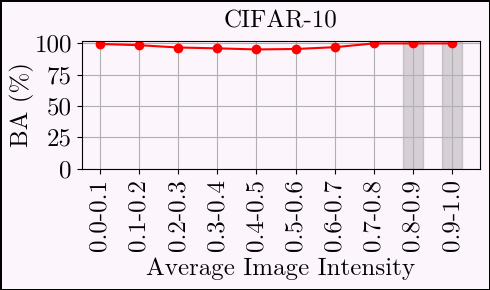

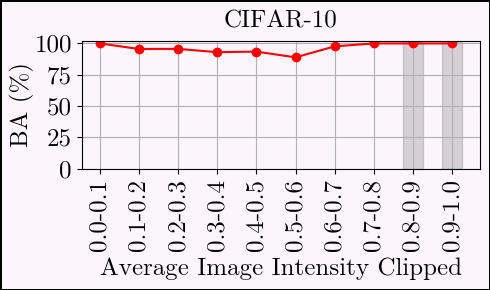

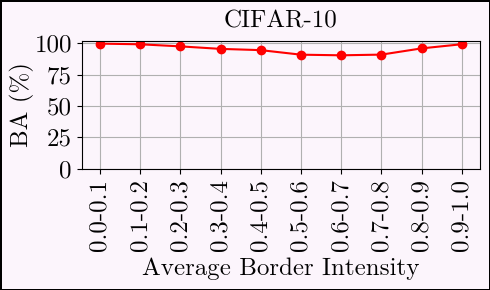

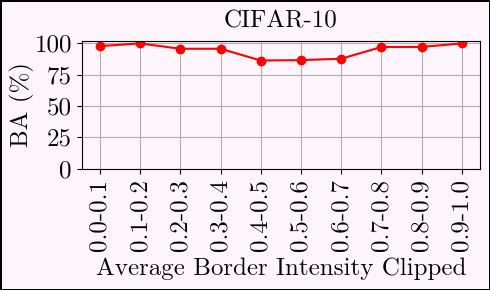

In [92]:
highlight_labels_by_group = {
    "Average Image Intensity": ["0.8-0.9", "0.9-1.0"],
    "Average Image Intensity Clipped": ["0.8-0.9", "0.9-1.0"],
}
to_download = []

# Plot results
for label, groups in results.items():
    for group_name, group_data in groups.items():
        # print(group_name)
        dataset_names = group_data["dataset_names"]
        clean_accuracies = group_data["test_accuracies"]
        asr_values = group_data["asr_values"]

        # Plot clean accuracy and ASR for the current group and label
        width, height = 5, 3
        # if 'clipped' in group_name.lower() and 'border' in group_name.lower():
        #     width = 4.6

        fig = plt.figure(figsize=(width, height))
        ax = plt.gca()

        # graying-code
        highlight_labels = set(highlight_labels_by_group.get(group_name, []))
        # map label -> categorical position (0..len(dataset_names)-1)
        pos = {name: i for i, name in enumerate(dataset_names)}  # categorical mapping [web:22]
        for name in highlight_labels:
            if name in pos:
                i = pos[name]
                ax.axvspan(i - 0.25, i + 0.25, color="black", alpha=0.15, zorder=0)  # band [web:2]

        plt.ylim([0, 102])
        fig.patch.set_facecolor(pink)
        fig.set_frameon(True)
        fig.patch.set_edgecolor("black")
        fig.patch.set_linewidth(2)
        ax.set_facecolor(pink)          
        ax.set_yticks([0, 25, 50, 75, 100])

        if "Class" in group_name:
          plt.plot(dataset_names, clean_accuracies, marker='o', label="Clean Accuracy", color='blue')
        plt.plot(dataset_names, asr_values, marker='o', label="BA", color='red')
        plt.xticks(rotation=90)
        plt.xlabel(group_name, fontproperties=font10, labelpad=5)
        plt.ylabel("BA (%)", fontproperties=font10, labelpad=0)
        plt.title(f'CIFAR-10', fontproperties=font10, pad=10)

        plt.grid(True)

        # Set font properties for x-axis ticks
        for tick_label in ax.get_xticklabels():
            tick_label.set_fontproperties(font10)

        # Set font properties for y-axis ticks
        for tick_label in ax.get_yticklabels():
            tick_label.set_fontproperties(font10)
             
        plt.tight_layout()
        # plt.show()
        file = f"fork_test_asr_vs_{group_name}.pdf"
        plt.savefig(file)
        to_download.append(file)

In [93]:
import os
import zipfile
from IPython.display import FileLink

def zip_and_download_pdfs(zip_name='all_plots.zip'):
    # Create a zip file
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        # Loop through all files in the current working directory
        found_files = False
        for root, dirs, files in os.walk('.'):
            for file in files:
                # Check if the file is a PDF (you can adjust this filter)
                if file in to_download:
                    zipf.write(os.path.join(root, file), arcname=file)
                    found_files = True
                    print(f"Added to zip: {file}")
    
    if found_files:
        print(f"\nSUCCESS: {zip_name} created successfully!")
        # specific to Kaggle/Jupyter to show a clickable link
        display(FileLink(zip_name))
    else:
        print("No PDF files found to zip. Did you uncomment plt.savefig()?")

# Run the function
zip_and_download_pdfs()

Added to zip: fork_test_asr_vs_Average Image Intensity.pdf
Added to zip: fork_test_asr_vs_Average Image Intensity Clipped.pdf
Added to zip: fork_test_asr_vs_Average Border Intensity.pdf
Added to zip: fork_test_asr_vs_Average Border Intensity Clipped.pdf

SUCCESS: all_plots.zip created successfully!


/kaggle/working/all_plots.zip

In [82]:
# # Plot results
# for label, groups in results.items():
#     for group_name, group_data in groups.items():
#         dataset_names = group_data["dataset_names"]
#         clean_accuracies = group_data["test_accuracies"]
        
#         # Plot clean accuracy and ASR for the current group and label
#         width, height = 4, 3
#         if 'clipped' in group_name.lower() and 'border' in group_name.lower():
#             width = 4.6

#         fig = plt.figure(figsize=(width, height))
#         ax = plt.gca()
#         # graying-code
#         highlight_labels = set(highlight_labels_by_group.get(group_name, []))
#         # map label -> categorical position (0..len(dataset_names)-1)
#         pos = {name: i for i, name in enumerate(dataset_names)}  # categorical mapping [web:22]
#         for name in highlight_labels:
#             if name in pos:
#                 i = pos[name]
#                 ax.axvspan(i - 0.25, i + 0.25, color="black", alpha=0.15, zorder=0)  # band [web:2]

#         plt.ylim(45, 102)
#         fig.patch.set_facecolor(pink)
#         fig.set_frameon(True)
#         fig.patch.set_edgecolor("black")
#         fig.patch.set_linewidth(2)
#         ax.set_facecolor(pink)                  

#         plt.plot(dataset_names, clean_accuracies, marker='o', label="Clean Accuracy", color='blue')
#         plt.xticks(rotation=90, ha='right')
#         plt.xlabel(group_name, fontproperties=font10, labelpad=10)
#         plt.ylabel("Clean ACC (%)", fontproperties=font10, labelpad=5)
#         # plt.legend()
#         plt.grid(True)
#         current_ax = plt.gca()

#         # Set font properties for x-axis ticks
#         for tick_label in current_ax.get_xticklabels():
#             tick_label.set_fontproperties(font10)

#         # Set font properties for y-axis ticks
#         for tick_label in current_ax.get_yticklabels():
#             tick_label.set_fontproperties(font10)
#         plt.tight_layout()
#         # plt.show()
#         plt.savefig(f"fork_test_clean_acc_vs_{group_name}.pdf")
#     #     break
#     # break